In [4]:

import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
import fitsio
import numpy as np
import pyarrow.parquet as pq
import pyarrow as pa
import scienceplots
plt.style.use(['science','notebook','grid'])
import glob
import os
from astropy.table import Table

In [5]:
files= glob.glob('/user/animesh.sah/w_theta_results/*')
matched_dr=Table(fitsio.FITS('/user/animesh.sah/DESI_PECVEL/DR_matched.fits')[1].read())

from scipy.stats import gaussian_kde
kde = gaussian_kde(matched_dr['Z'],bw_method=0.25)
samples = kde.resample(700).flatten()
samples = np.clip(samples, 0, None)
y_samples=kde.evaluate(samples)
samples_sorted=np.sort(samples)
arg=np.argsort(samples)
y_samples_sorted= y_samples[arg]

# plt.hist(matched_dr['Z'],bins=30,edgecolor='blue',label='DESI Spectral',density=True)

# plt.plot(samples_sorted,y_samples_sorted,'.',alpha=0.6)
z=samples_sorted
n_z=y_samples_sorted
n_z /= np.trapz(y_samples_sorted, samples_sorted)
from astropy.cosmology import Planck18 as cosmo
import astropy.units as u
dL = cosmo.comoving_distance(samples_sorted).to(u.Mpc).value
num  = np.trapz(dL*n_z**2, z)
denom  = np.trapz(n_z**2, z)
chi_eff = num/denom
def theta_to_r(theta_deg):
    return chi_eff * np.deg2rad(theta_deg)

def r_to_theta(r_mpc):
    return np.rad2deg(r_mpc / chi_eff)


zeff = np.trapz(z*n_z, z) /np.trapz(n_z, z)
print('zeff = ', zeff)
dc_zeff= cosmo.comoving_distance(zeff).to(u.Mpc).value
dc_zeff

def theta_to_r_dc(theta_deg):
    return dc_zeff * np.deg2rad(theta_deg)
def r_to_theta_dc(r_mpc):
    return np.rad2deg(r_mpc / dc_zeff)

zeff =  0.09153080148182423


In [6]:
#files

files_point = np.sort([file for file in files if  'jackknife'  not in file and 'bootstrap' not in file and  '0.001_to_100' in file ])


In [7]:
# color = ['k','r','b','g']
# fig,ax = plt.subplots(figsize=(17,12))
# for file in files_point: 
#     dat = np.load(file)
#     name = os.path.basename(file)
#     name = name.replace('.npy','')
#     name = name.split('_')[1] + '(' + name.split('_')[0] + ')'
#     if  'corrfunc' in name:
#         ax.plot(dat[0],dat[1],label=name,marker='*',linestyle='None')
#     else: 
#         ax.plot(dat[0],dat[1],label=name,marker='.',linestyle='None')
#     #plt.plot(dat[0],dat[1],label=name,marker='.',linestyle='None')

# plt.legend()
# ax.set_xscale('log')
# ax.set_yscale('log')
# ax.set_xlabel(r'$\theta$ (degrees)')
# ax.set_ylabel(r'$w_{\theta}$')
# secax = ax.secondary_xaxis('top',
# functions=(theta_to_r_dc,r_to_theta_dc))
# secax.set_xlabel(r'Projected comoving distance $r_\perp$ (Mpc)')
# secax.set_xscale('log')
# #ax.vlines(x=r_to_theta(np.array([1,2,3,4,5,6,7,8,9,10])), ymin=1e-8, ymax=2e2, color='r', linestyle='--', label=r'$\theta$ = 0.147 deg')
# secax = ax.secondary_xaxis('top', functions=(theta_to_r_dc, r_to_theta_dc))
# secax.tick_params(axis='x', which='both', length=0)  # removes the tick marks, keeps labels
# ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True)
# plt.legend()

In [8]:
# files= glob.glob('/user/animesh.sah/w_theta_results/*')

# plt.figure(figsize=(15,10))
# files = [file for file in files if '100' in file]
# color = ['k','r','b','g']
# for file in files: 

#     dat = np.load(file)
#     name = os.path.basename(file)
#     name = name.replace('.npy','')
#     name = name.split('_')[1] + '(' + name.split('_')[0] + ')'
#     plt.plot(dat[0],dat[1],label=name,marker='.',linestyle='None')
#     #plt.plot(dat[0],dat[1],label=name,marker='.',linestyle='None')
#     plt.xscale('log')
#     plt.yscale('log')
# plt.legend()

In [9]:
# files= glob.glob('/user/animesh.sah/w_theta_results/*')

# files = [file for file in files if '100' in file]


# part = ['north','south','full']


# {patch: [file for file in files if patch in file] for patch in part}


# for patch in part:
#     plt.figure(figsize=(15,10))

#     files_sub = [file for file in files if patch in file]
#     ar = []
#     for file in files_sub:
#         dat = np.load(file)
#         name = os.path.basename(file)
#         name = name.replace('.npy','')
#         name = name.split('_')[1] + '(' + name.split('_')[0] + ')'
#         ar.append(dat[1])
#         #plt.plot(dat[0],dat[1],label=name,marker='.',linestyle='None')
#     plt.plot(dat[0],100*(ar[0]-ar[1])/ar[0],'.')
#     plt.ylabel(r'$(w_{\theta, treecorr} - w_{\theta, corrfunc})/w_{\theta, treecorr} \times 100$')
#     plt.xscale('log')
#     plt.yscale('symlog', linthresh=0.1)

#     plt.title(patch)
#     plt.legend()
#     plt.show()


# # for file in files: 
# #     dat = np.load(file)
# #     name = os.path.basename(file)
# #     name = name.replace('.npy','')
# #     name = name.split('_')[1] + '(' + name.split('_')[0] + ')'

# #   if 'north' in name:
# #         ar1 = 

        
# #     plt.plot(dat[0],dat[1],label=name,marker='.',linestyle='None')
# #     #plt.plot(dat[0],dat[1],label=name,marker='.',linestyle='None')
# #     plt.xscale('log')
# #     plt.yscale('log')
# # plt.legend()


In [10]:
# files= glob.glob('/user/animesh.sah/w_theta_results/*')

# files = [file for file in files if '100' in file]


# part = ['north','south','full']


# {patch: [file for file in files if patch in file] for patch in part}


# for patch in part:
#     plt.figure(figsize=(15,10))

#     files_sub = [file for file in files if patch in file]
#     ar = []
#     for file in files_sub:
#         dat = np.load(file)
#         name = os.path.basename(file)
#         name = name.replace('.npy','')
#         name = name.split('_')[1] + '(' + name.split('_')[0] + ')'
#         ar.append(dat[1])
#         #plt.plot(dat[0],dat[1],label=name,marker='.',linestyle='None')
#     plt.plot(dat[0],100*(ar[0]-ar[1])/ar[0],'.')
#     plt.ylabel(r'$(w_{\theta, treecorr} - w_{\theta, corrfunc})/w_{\theta, treecorr} \times 100$')
#     # plt.xscale('log')
#     # plt.yscale('symlog', linthresh=0.1)

#     plt.title(patch)
#     plt.legend()
#     plt.show()


# # for file in files: 
# #     dat = np.load(file)
# #     name = os.path.basename(file)
# #     name = name.replace('.npy','')
# #     name = name.split('_')[1] + '(' + name.split('_')[0] + ')'

# #   if 'north' in name:
# #         ar1 = 

        
# #     plt.plot(dat[0],dat[1],label=name,marker='.',linestyle='None')
# #     #plt.plot(dat[0],dat[1],label=name,marker='.',linestyle='None')
# #     plt.xscale('log')
# #     plt.yscale('log')
# # plt.legend()


In [11]:
# files= glob.glob('/user/animesh.sah/w_theta_results/*')

# files_jackknife_200 = np.sort([file for file in files if  'jackknife'  in file and '200' in file])

# files_bootstrap = np.sort([file for file in files if  'bootstrap'  in file and 'treecorr' in file])
# #part = ['north','south','full']


# #{patch: [file for file in files if patch in file] for patch in part}

# #plt.figure(figsize=(15,10))
# fig, ax = plt.subplots(figsize=(15,10))

# for file in files_jackknife_200:
#     dat = np.load(file)
#     name = os.path.basename(file)
#     name = name.replace('.npy','')
#     name = name.split('_')[1] + '(' + name.split('_')[0] + ')'
#     ax.set_title('Jackknife resampling (200 patches)')
#     ax.errorbar(dat[0][::2],dat[1][::2],yerr=dat[2][::2],label=name,marker='*',linestyle='None',capsize=3,alpha=0.8)
# ax.set_xscale('log')
# ax.set_yscale('log')
# ax.set_xlabel(r'$\theta$ (degrees)')
# ax.set_ylabel(r'$w_{\theta}$')
# secax = ax.secondary_xaxis('top',
# functions=(theta_to_r_dc,r_to_theta_dc))
# secax.set_xlabel(r'Projected comoving distance $r_\perp$ (Mpc)')
# secax.set_xscale('log')
# #ax.vlines(x=r_to_theta(np.array([1,2,3,4,5,6,7,8,9,10])), ymin=1e-8, ymax=2e2, color='r', linestyle='--', label=r'$\theta$ = 0.147 deg')
# secax = ax.secondary_xaxis('top', functions=(theta_to_r_dc, r_to_theta_dc))
# secax.tick_params(axis='x', which='both', length=0)  # removes the tick marks, keeps labels
# ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True)
# plt.legend()


# fig, ax = plt.subplots(figsize=(15,10))

# for file in files_bootstrap:
#     dat = np.load(file)
#     name = os.path.basename(file)
#     name = name.replace('.npy','')
#     name = name.split('_')[1] + '(' + name.split('_')[0] + ')'
#     ax.set_title('Bootstrap resampling')
#     ax.errorbar(dat[0][::2],dat[1][::2],yerr=dat[2][::2],label=name,marker='*',linestyle='None',capsize=3,alpha=0.8)
#     ax.set_xscale('log')
#     ax.set_yscale('log')
#     ax.set_xlabel(r'$\theta$ (degrees)')
#     ax.set_ylabel(r'$w_{\theta}$')
#     secax = ax.secondary_xaxis('top',
#     functions=(theta_to_r_dc,r_to_theta_dc))
#     secax.set_xlabel(r'Projected comoving distance $r_\perp$ (Mpc)')
# ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True)

# plt.legend()


# # for file in files: 
# #     dat = np.load(file)
# #     name = os.path.basename(file)
# #     name = name.replace('.npy','')
# #     name = name.split('_')[1] + '(' + name.split('_')[0] + ')'

# #   if 'north' in name:
# #         ar1 = 

        
# #     plt.plot(dat[0],dat[1],label=name,marker='.',linestyle='None')
# #     #plt.plot(dat[0],dat[1],label=name,marker='.',linestyle='None')
# #     plt.xscale('log')
# #     plt.yscale('log')
# # plt.legend()


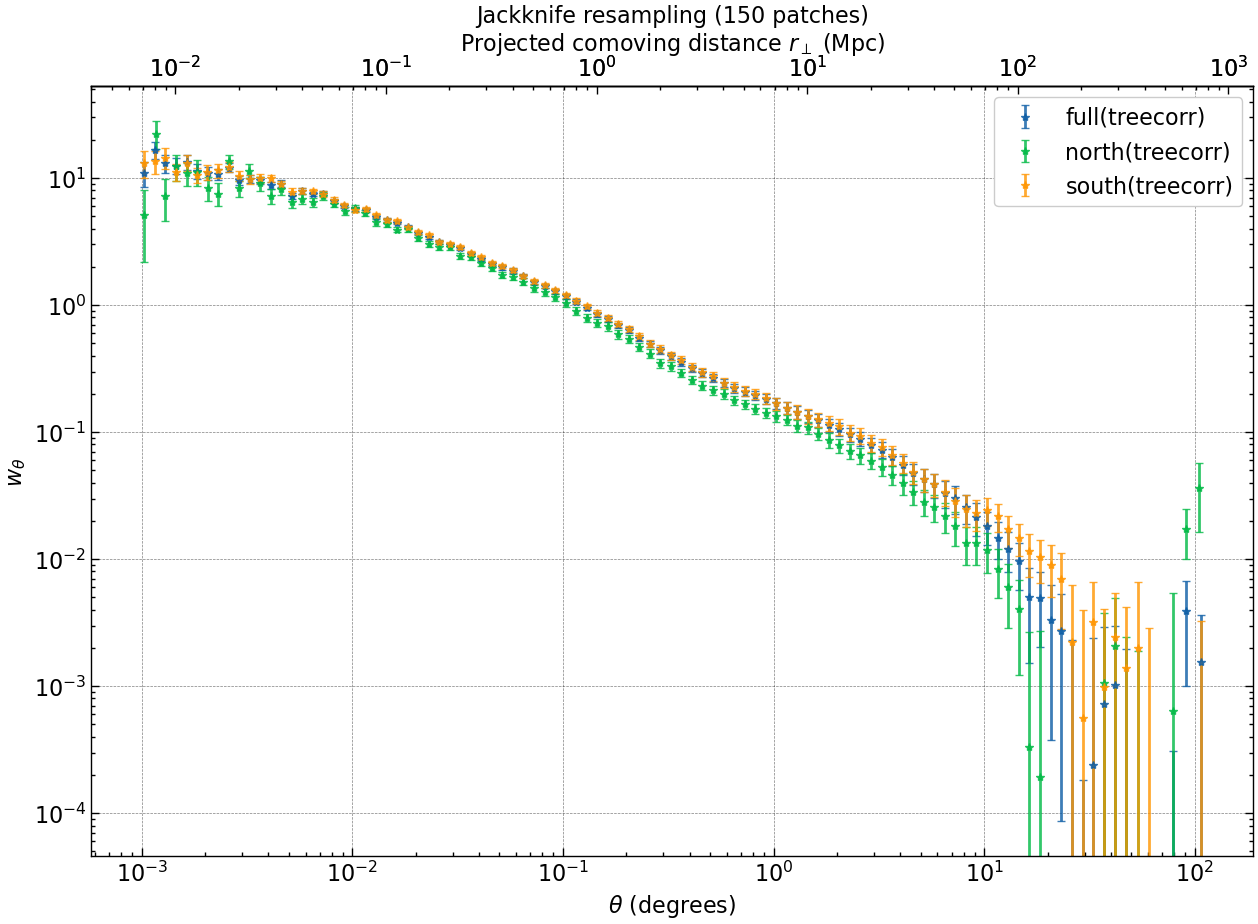

In [12]:

files_jackknife_150 = [file for file in files if  'jackknife'  in file and '150' in file]



#{patch: [file for file in files if patch in file] for patch in part}

fig, ax = plt.subplots(figsize=(15,10))
for file in files_jackknife_150:
    dat = np.load(file)
    name = os.path.basename(file)
    name = name.replace('.npy','')
    name = name.split('_')[1] + '(' + name.split('_')[0] + ')'
    ax.set_title('Jackknife resampling (150 patches)')
    ax.errorbar(dat[0][::2],dat[1][::2],yerr=dat[2][::2],label=name,marker='*',linestyle='None',capsize=3,alpha=0.8)
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\theta$ (degrees)')
plt.ylabel(r'$w_{\theta}$')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$\theta$ (degrees)')
ax.set_ylabel(r'$w_{\theta}$')
secax = ax.secondary_xaxis('top',
functions=(theta_to_r_dc,r_to_theta_dc))
secax.set_xlabel(r'Projected comoving distance $r_\perp$ (Mpc)')
secax.set_xscale('log')
#ax.vlines(x=r_to_theta(np.array([1,2,3,4,5,6,7,8,9,10])), ymin=1e-8, ymax=2e2, color='r', linestyle='--', label=r'$\theta$ = 0.147 deg')
secax = ax.secondary_xaxis('top', functions=(theta_to_r_dc, r_to_theta_dc))
secax.tick_params(axis='x', which='both', length=0)  # removes the tick marks, keeps labels
ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True)
plt.legend()

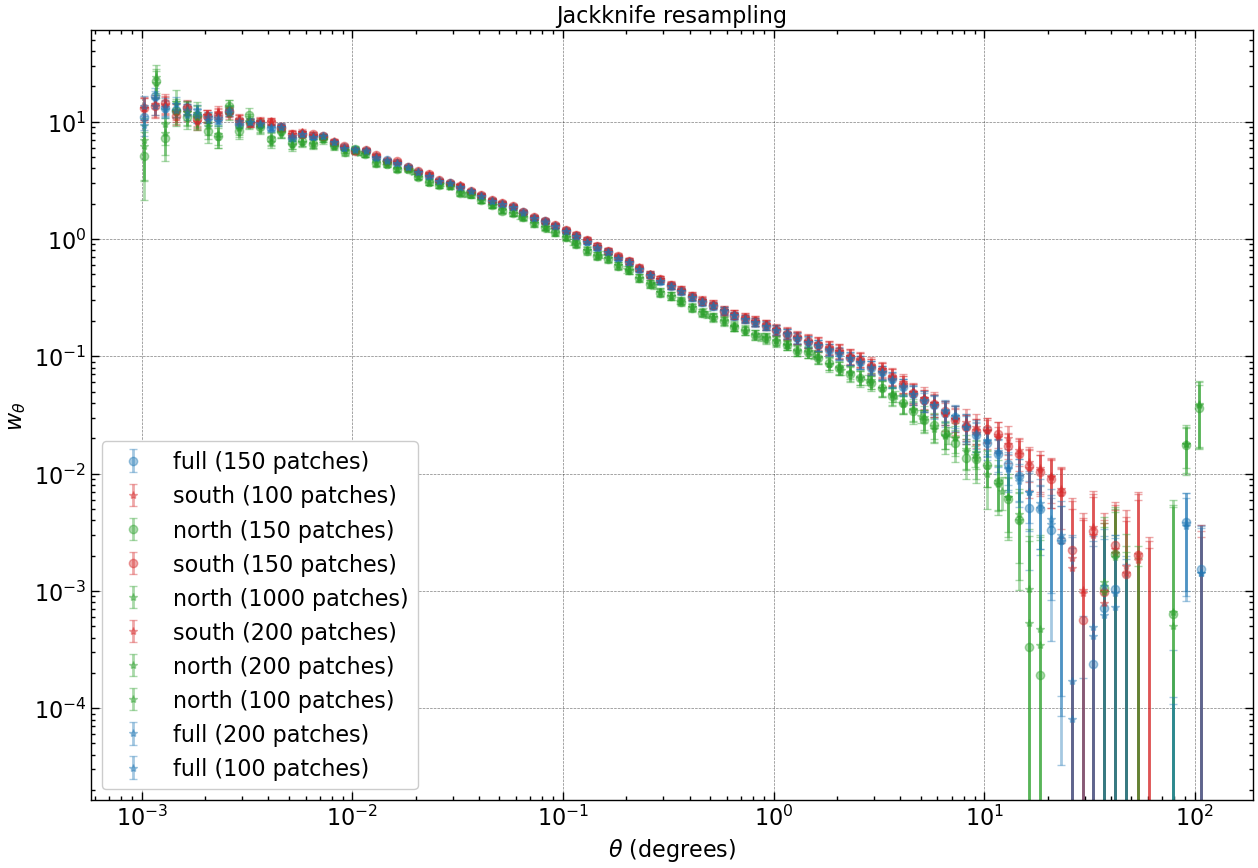

In [13]:
files_jackknife = [file for file in files if  'jackknife'  in file and 'treecorr' in file]

plt.figure(figsize=(15,10))

region_colors = {
    "north": "tab:green",
    "south": "tab:red",
    "full":  "tab:blue"
}
patch_styles = {
    "150": {"marker": "o"},
    "200": {"marker": "*"}
}
for file in files_jackknife:
    dat = np.load(file)
    name = os.path.basename(file).replace(".npy", "")

    # parse region and patch number from filename
    parts = name.split("_")
    region = parts[1]   # full, south, north
    patchnum = parts[4] # 150 or 200

    color = region_colors.get(region, "black")
    style = patch_styles.get(patchnum, {"marker": "*", "linestyle": "None"})

    label = f"{region} ({patchnum} patches)"
    try:
        plt.errorbar(
            dat[0][::2], dat[1][::2], yerr=dat[2][::2],
            label=label,
            color=color,
            marker=style["marker"],
            linestyle='None',
            capsize=3,
            alpha=0.4
        )
    except Exception as e:
        print(f"Error plotting {name}: {e}")

plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$\theta$ (degrees)")
plt.ylabel(r"$w_{\theta}$")
plt.title("Jackknife resampling")
plt.legend()
plt.show()

In [14]:


# from matplotlib.colors import LogNorm
# plt.matshow(abs(mat), cmap='viridis', norm=LogNorm())
# plt.colorbar()

In [15]:
plt.loglog(corrfunc_south_jk[0][0],np.mean(corrfunc_south_jk[:,1],axis =0),'.')
plt.loglog(corrfunc_south[0],corrfunc_south[1],'r.')

NameError: name 'corrfunc_south_jk' is not defined

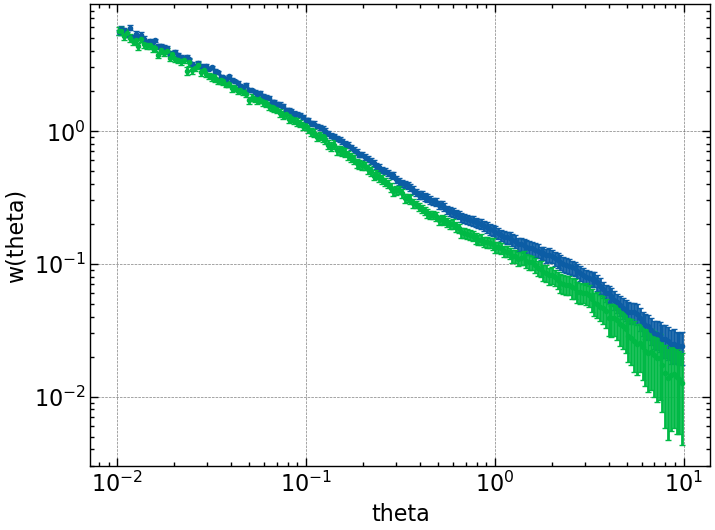

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# load
corrfunc_south_jk = np.load('/user/animesh.sah/w_theta_results/corrfunc_south_jackknife_patches_nside_6_128_0.01_to_10_v2.npy',
                            allow_pickle=True)
corrfunc_south = np.load('/user/animesh.sah/w_theta_results/corrfunc_south_0.01_to_10.npy',
                         allow_pickle=True)
corrfunc_north = np.load('/user/animesh.sah/w_theta_results/corrfunc_north_0.01_to_10.npy',
                         allow_pickle=True)

corrfunc_north_jk = np.load('/user/animesh.sah/w_theta_results/corrfunc_north_jackknife_patches_nside_6_59_0.01_to_10_v2.npy',
                            allow_pickle=True)

def jackknife_errors(jackknife_file,point_estimate_file):

    
    w_jk = jackknife_file[:,1]
    w_pe = point_estimate_file[1]
    theta = point_estimate_file[0]
    N = w_jk.shape[0]
    w_mean = np.mean(w_jk, axis=0)
    
    d = (w_jk - w_mean)
    cov = (N - 1) / N * (d.T @ d)
    
    var = np.diag(cov)
    err = np.sqrt(var)
    
    return theta, w_pe,err
south_jk = jackknife_errors(corrfunc_south_jk, corrfunc_south)
north_jk = jackknife_errors(corrfunc_north_jk, corrfunc_north)
# plot (errorbars in linear space, then set log scales)
plt.errorbar(south_jk[0], south_jk[1], yerr=south_jk[2], fmt='.', capsize=2)
plt.errorbar(north_jk[0], north_jk[1], yerr=north_jk[2], fmt='.', capsize=2)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('theta')
plt.ylabel('w(theta)')
plt.show()


In [ ]:
treecorr_south_jk = np.load('/user/animesh.sah/w_theta_results/treecorr_south_jackknife_patches_150_0.001_to_100.npy')
treecorr_north_jk = np.load('/user/animesh.sah/w_theta_results/treecorr_north_bootstrap_patches_100_0.005_to_15.npy')
#treecorr_north_jk_v2 = np.load('/user/animesh.sah/w_theta_results/treecorr_north_jackknife_patches_192_0.005_to_15.npy')                      

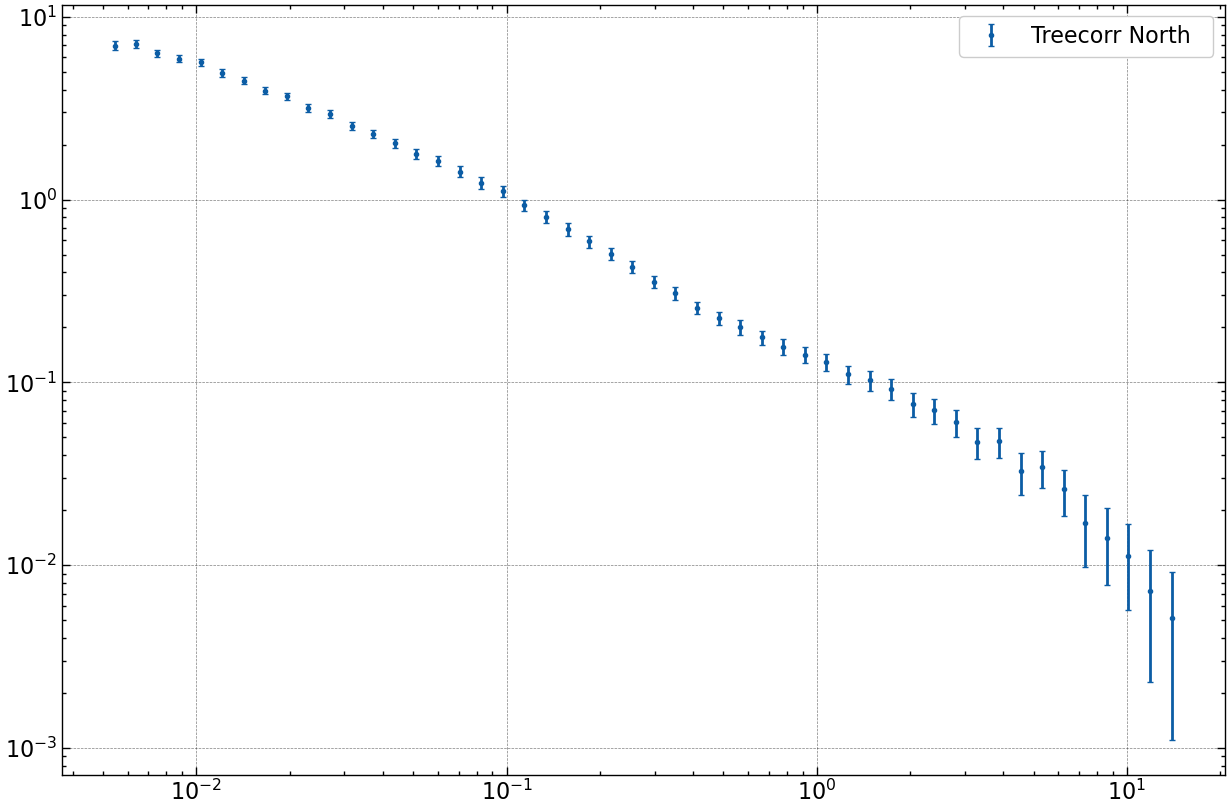

In [ ]:
plt.figure(figsize=(15,10))
#plt.errorbar(treecorr_south_jk[0][::2], treecorr_south_jk[1][::2], yerr=treecorr_south_jk[2][::2], fmt='.', capsize=2,label ='Treecorr South  ')
plt.errorbar(treecorr_north_jk[0], treecorr_north_jk[1], yerr=treecorr_north_jk[2], fmt='.', capsize=2,label ='Treecorr North  ')
# plt.errorbar(south_jk[0][::2], south_jk[1][::2], yerr=south_jk[2][::2], fmt='.', capsize=2,label ='Corrfunc South  ')
# plt.errorbar(north_jk[0], north_jk[1], yerr=north_jk[2], fmt='.', capsize=2,label ='Corrfunc North  ')

plt.xscale('log')
plt.yscale('log')
plt.legend()



In [21]:
import re
import matplotlib.cm as cm

def extract_patch_num(path):
    # pulls out the number right after "patches_"
    m = re.search(r'patches_(\d+)_', path)
    return int(m.group(1)) if m else float('inf')



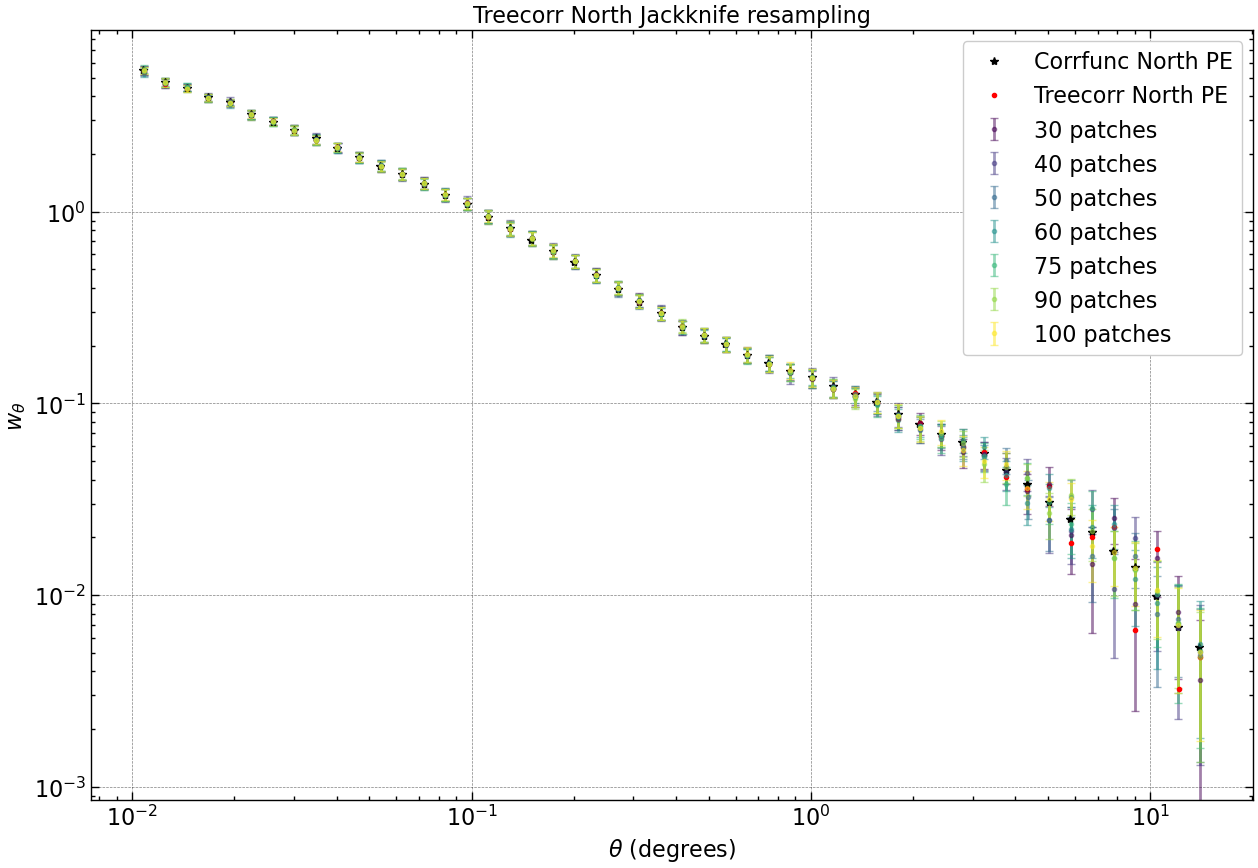

In [22]:
files_jackknife_north = np.array(glob.glob('/user/animesh.sah/w_theta_results/0.01_to_15/treecorr_north_jackknife_*_0.01_to_15.npy'))
files_jackknife_north = sorted(files_jackknife_north, key=extract_patch_num)
file_point_estimate_north_corrfunc = '/user/animesh.sah/w_theta_results/0.01_to_15/corrfunc_north_0.01_to_15.npy'
file_point_estimate_north_treecorr = '/user/animesh.sah/w_theta_results/0.01_to_15/treecorr_north_0.01_to_15.npy'
plt.figure(figsize=(15,10))
colors = cm.viridis(np.linspace(0, 1, len(files_jackknife_north)))
for i,jk_file in enumerate(files_jackknife_north):
    dat = np.load(jk_file)
    name = os.path.basename(jk_file)
    name = name.replace('.npy','')
    parts = name.split('_')
    num_patches = parts[4]
    corrfunc_estimate = np.load(file_point_estimate_north_corrfunc)
    treecorr_estimate = np.load(file_point_estimate_north_treecorr)
    plt.errorbar(dat[0],dat[1],yerr=dat[2],color=colors[i],label=f'{num_patches} patches',marker='.',linestyle='None',capsize=3,alpha=0.5)
plt.plot(corrfunc_estimate[0],corrfunc_estimate[1],label='Corrfunc North PE',color='black',marker='*',linestyle='None',alpha=1)
plt.plot(treecorr_estimate[0],treecorr_estimate[1],label='Treecorr North PE',color='red',marker='.',linestyle='None',alpha=1)

plt.xscale('log')
plt.yscale('log')

plt.title('Treecorr North Jackknife resampling')
plt.xlabel(r'$\theta$ (degrees)')
plt.ylabel(r'$w_{\theta}$')
plt.legend()
plt.show()

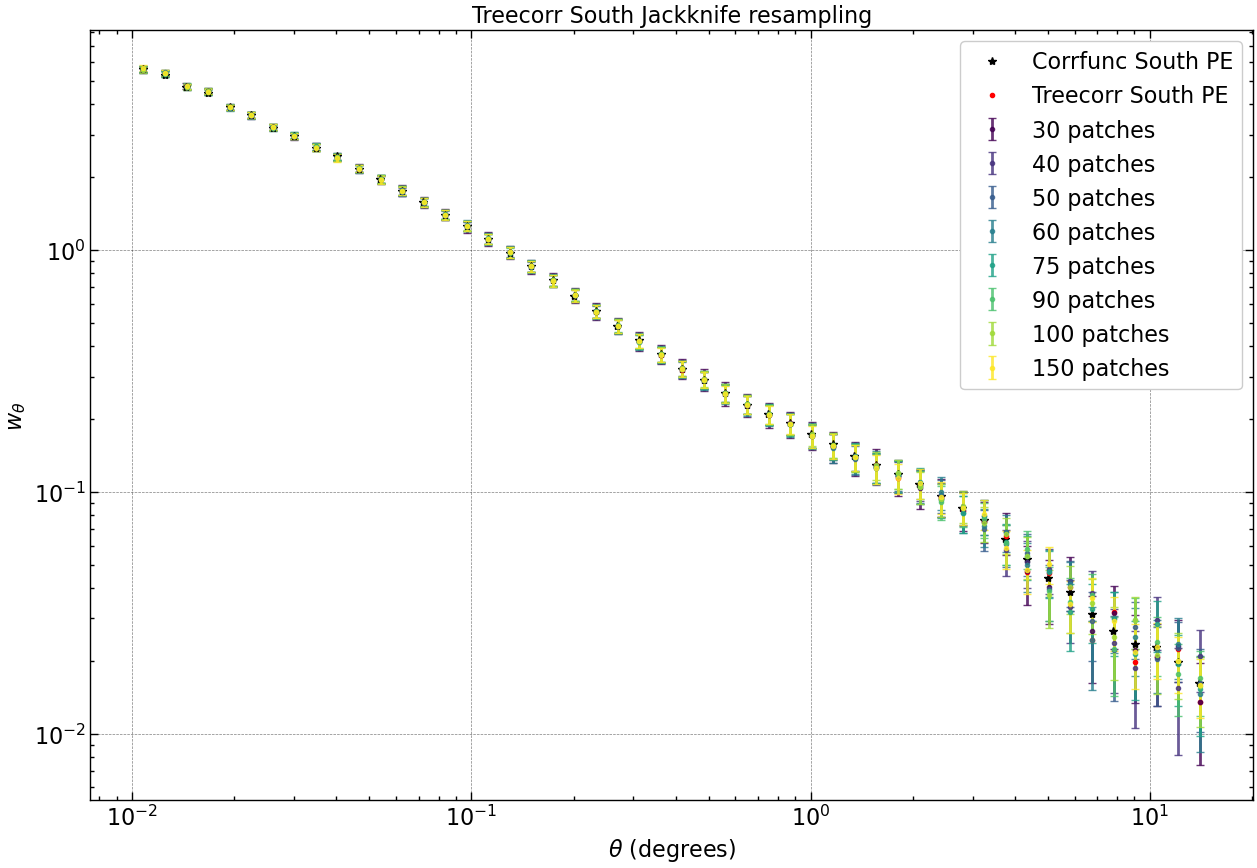

In [23]:
files_jackknife_south = np.array(glob.glob('/user/animesh.sah/w_theta_results/0.01_to_15/treecorr_south_jackknife_*_0.01_to_15.npy'))
files_jackknife_south = sorted(files_jackknife_south, key=extract_patch_num)
file_point_estimate_south_corrfunc = '/user/animesh.sah/w_theta_results/0.01_to_15/corrfunc_south_0.01_to_15.npy'
file_point_estimate_south_treecorr = '/user/animesh.sah/w_theta_results/0.01_to_15/treecorr_south_0.01_to_15.npy'
plt.figure(figsize=(15,10))
colors = cm.viridis(np.linspace(0, 1, len(files_jackknife_south)))
for i, jk_file in enumerate(files_jackknife_south):
    dat = np.load(jk_file)
    name = os.path.basename(jk_file)
    name = name.replace('.npy','')
    parts = name.split('_')
    num_patches = int(parts[4])
    #if num_patches > 80:
    plt.errorbar(dat[0], dat[1], yerr=dat[2], color=colors[i], label=f'{num_patches} patches', marker='.', linestyle='None', capsize=3, alpha=0.8)

corrfunc_estimate = np.load(file_point_estimate_south_corrfunc)
treecorr_estimate = np.load(file_point_estimate_south_treecorr)
plt.plot(corrfunc_estimate[0], corrfunc_estimate[1], label='Corrfunc South PE', color='black', marker='*', linestyle='None', alpha=1)
plt.plot(treecorr_estimate[0], treecorr_estimate[1], label='Treecorr South PE', color='red', marker='.', linestyle='None', alpha=1)

plt.xscale('log')
plt.yscale('log')

plt.title('Treecorr South Jackknife resampling')
plt.xlabel(r'$\theta$ (degrees)')
plt.ylabel(r'$w_{\theta}$')
plt.legend()
plt.show()

In [37]:
files_bootstrap_north

array(['/user/animesh.sah/w_theta_results/0.01_to_15/treecorr_north_bootstrap_patches_100_1000_0.01_to_15.npy',
       '/user/animesh.sah/w_theta_results/0.01_to_15/treecorr_north_bootstrap_patches_150_500_0.01_to_15.npy',
       '/user/animesh.sah/w_theta_results/0.01_to_15/treecorr_north_bootstrap_patches_100_200_0.01_to_15.npy',
       '/user/animesh.sah/w_theta_results/0.01_to_15/treecorr_north_bootstrap_patches_120_500_0.01_to_15.npy',
       '/user/animesh.sah/w_theta_results/0.01_to_15/treecorr_north_bootstrap_patches_150_2000_0.01_to_15.npy',
       '/user/animesh.sah/w_theta_results/0.01_to_15/treecorr_north_bootstrap_patches_40_500_0.01_to_15.npy',
       '/user/animesh.sah/w_theta_results/0.01_to_15/treecorr_north_bootstrap_patches_150_200_0.01_to_15.npy',
       '/user/animesh.sah/w_theta_results/0.01_to_15/treecorr_north_bootstrap_patches_30_200_0.01_to_15.npy',
       '/user/animesh.sah/w_theta_results/0.01_to_15/treecorr_north_bootstrap_patches_30_1000_0.01_to_15.npy',
 

In [50]:
from collections import defaultdict

base_dir = "/user/animesh.sah/w_theta_results/0.01_to_15"
pattern = re.compile(r"treecorr_north_bootstrap_patches_(\d+)_(\d+)_0\.01_to_15\.npy$")
def group_files_by_nboot(base_dir, pattern):
    files_by_nboot = defaultdict(list)
    for fname in os.listdir(base_dir):
        match = pattern.match(fname)
        if match:
            patch, n_boot = match.groups()
            n_boot = int(n_boot)
            full_path = os.path.join(base_dir, fname)
            files_by_nboot[n_boot].append(full_path)

    # Convert defaultdict to normal dict if you want
    files_by_nboot = dict(files_by_nboot)
    return files_by_nboot
files_by_nboot_north = group_files_by_nboot(base_dir, pattern)

['/user/animesh.sah/w_theta_results/0.01_to_15/treecorr_north_bootstrap_patches_100_1000_0.01_to_15.npy',
 '/user/animesh.sah/w_theta_results/0.01_to_15/treecorr_north_bootstrap_patches_30_1000_0.01_to_15.npy',
 '/user/animesh.sah/w_theta_results/0.01_to_15/treecorr_north_bootstrap_patches_150_1000_0.01_to_15.npy',
 '/user/animesh.sah/w_theta_results/0.01_to_15/treecorr_north_bootstrap_patches_40_1000_0.01_to_15.npy',
 '/user/animesh.sah/w_theta_results/0.01_to_15/treecorr_north_bootstrap_patches_90_1000_0.01_to_15.npy',
 '/user/animesh.sah/w_theta_results/0.01_to_15/treecorr_north_bootstrap_patches_75_1000_0.01_to_15.npy',
 '/user/animesh.sah/w_theta_results/0.01_to_15/treecorr_north_bootstrap_patches_50_1000_0.01_to_15.npy',
 '/user/animesh.sah/w_theta_results/0.01_to_15/treecorr_north_bootstrap_patches_60_1000_0.01_to_15.npy',
 '/user/animesh.sah/w_theta_results/0.01_to_15/treecorr_north_bootstrap_patches_120_1000_0.01_to_15.npy']

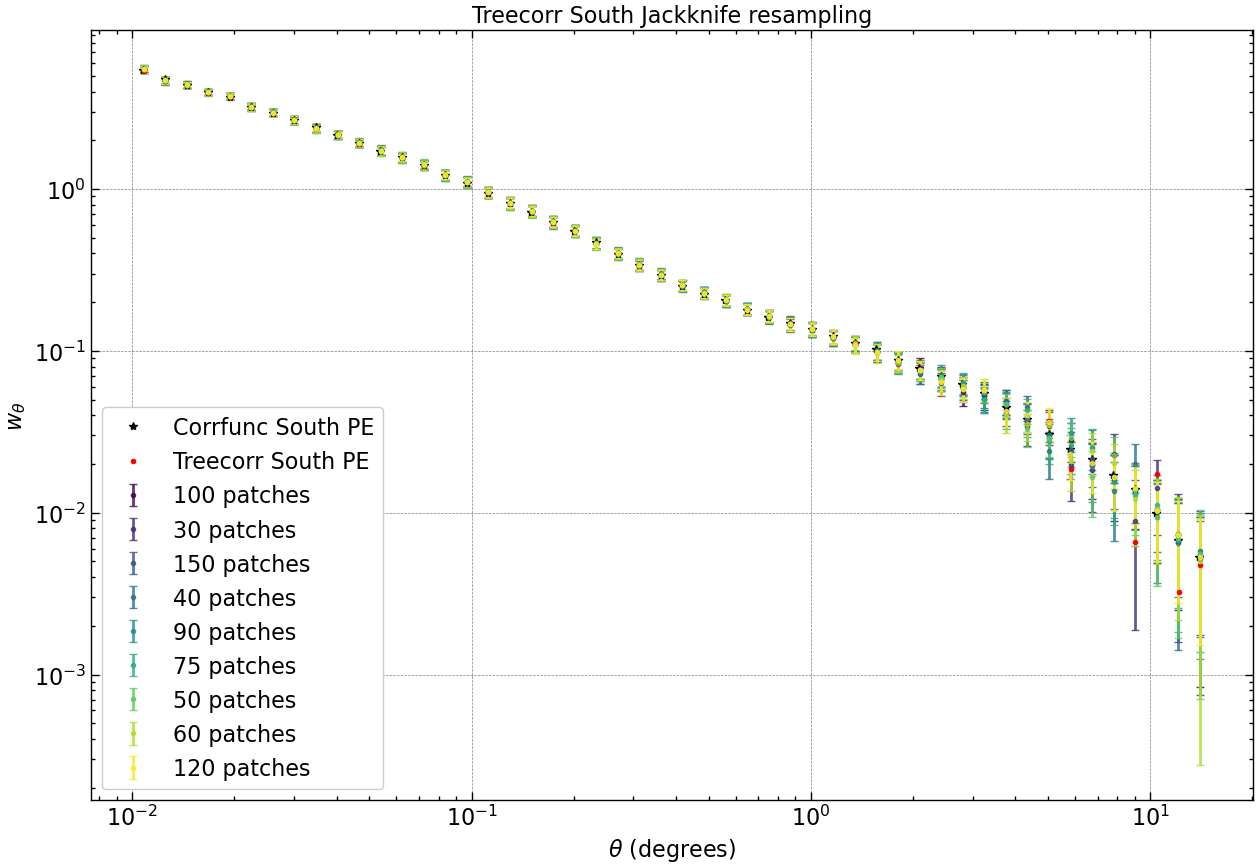

In [51]:
# files_bootstrap_north = sorted(files_bootstrap_south, key=extract_patch_num)
file_point_estimate_south_corrfunc = '/user/animesh.sah/w_theta_results/0.01_to_15/corrfunc_south_0.01_to_15.npy'
file_point_estimate_south_treecorr = '/user/animesh.sah/w_theta_results/0.01_to_15/treecorr_south_0.01_to_15.npy'
plt.figure(figsize=(15,10))
colors = cm.viridis(np.linspace(0, 1, len(files_by_nboot_north[1000])))
for i, jk_file in enumerate(files_by_nboot_north[1000]):
    dat = np.load(jk_file)
    name = os.path.basename(jk_file)
    name = name.replace('.npy','')
    parts = name.split('_')
    num_patches = int(parts[4])
    #if num_patches > 80:
    plt.errorbar(dat[0], dat[1], yerr=dat[2], color=colors[i], label=f'{num_patches} patches', marker='.', linestyle='None', capsize=3, alpha=0.8)

corrfunc_estimate = np.load(file_point_estimate_north_corrfunc)
treecorr_estimate = np.load(file_point_estimate_north_treecorr)
plt.plot(corrfunc_estimate[0], corrfunc_estimate[1], label='Corrfunc South PE', color='black', marker='*', linestyle='None', alpha=1)
plt.plot(treecorr_estimate[0], treecorr_estimate[1], label='Treecorr South PE', color='red', marker='.', linestyle='None', alpha=1)

plt.xscale('log')
plt.yscale('log')

plt.title('Treecorr South Jackknife resampling')
plt.xlabel(r'$\theta$ (degrees)')
plt.ylabel(r'$w_{\theta}$')
plt.legend()
plt.show()

In [ ]:
gal_tracer = ccl.NumberCountsTracer(cosmo, has_rsd=False, dndz=(z, n_z), bias=(z, np.ones_like(z)))
cl = ccl.angular_cl(cosmo, gal_tracer, gal_tracer, ell)
theta = np.logspace(0.75, 1.2, 50)  # in radians (~0.06° to 57°)
wtheta = ccl.correlation( cosmo=cosmo,ell=ell, C_ell=cl, theta=theta)
wtheta

array([0.00850039, 0.00822705, 0.0079595 , 0.00769769, 0.00744158,
       0.00719115, 0.00694636, 0.0067072 , 0.00647364, 0.00624565,
       0.00602317, 0.00580612, 0.00559446, 0.00538814, 0.00518714,
       0.00499143, 0.00480093, 0.00461557, 0.00443526, 0.00425996,
       0.00408966, 0.00392431, 0.00376383, 0.00360812, 0.00345712,
       0.0033108 , 0.00316912, 0.00303199, 0.0028993 , 0.00277098,
       0.00264702, 0.00252738, 0.00241195, 0.00230066, 0.0021935 ,
       0.00209047, 0.0019915 , 0.00189648, 0.00180545, 0.00171839,
       0.00163521, 0.00155583, 0.00148029, 0.00140852, 0.00134036,
       0.00127573, 0.00121453, 0.00115647, 0.00110132, 0.00104891])

In [ ]:


from scipy.optimize import curve_fit as cf
def wfunc(theta,a):
    wtheta = ccl.correlation( cosmo=cosmo,ell=ell, C_ell=cl, theta=theta)

    return a*wtheta




[2.32364036]
[5.39930452]


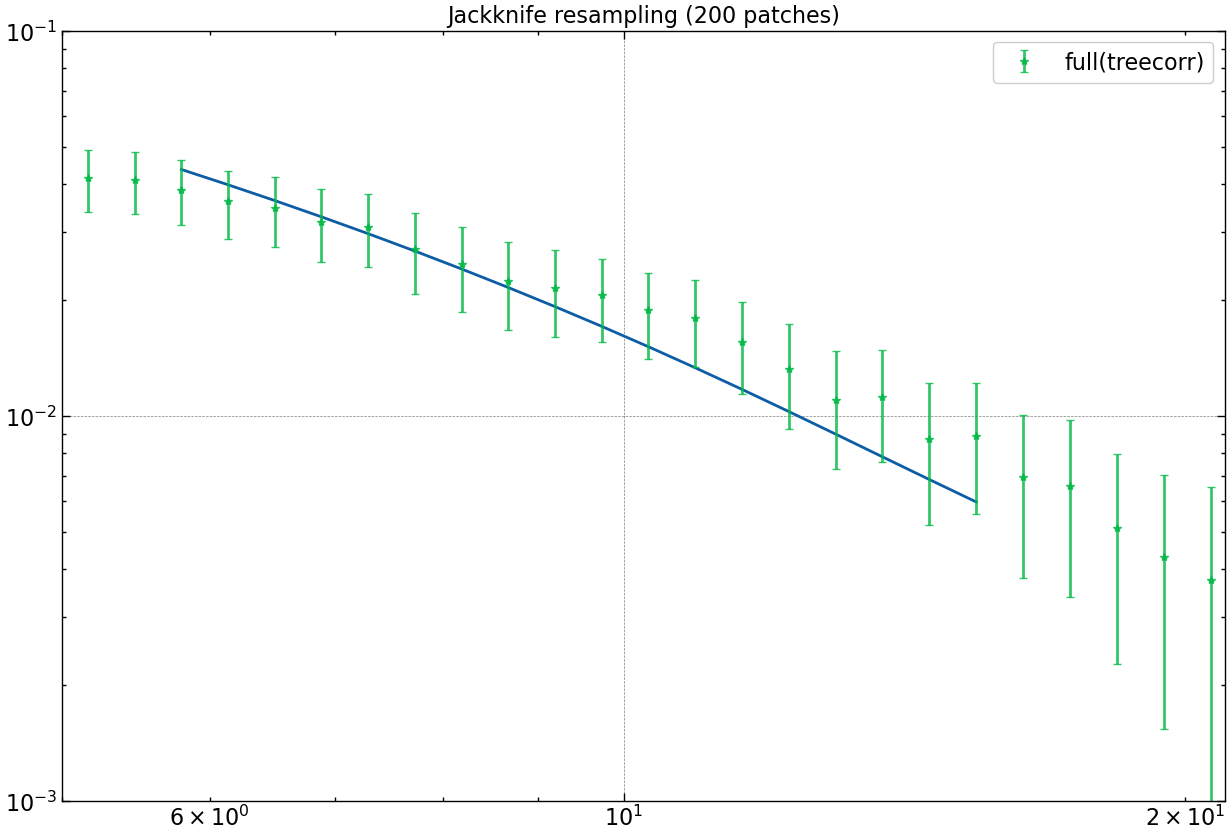

[1.82724364]
[3.33881931]


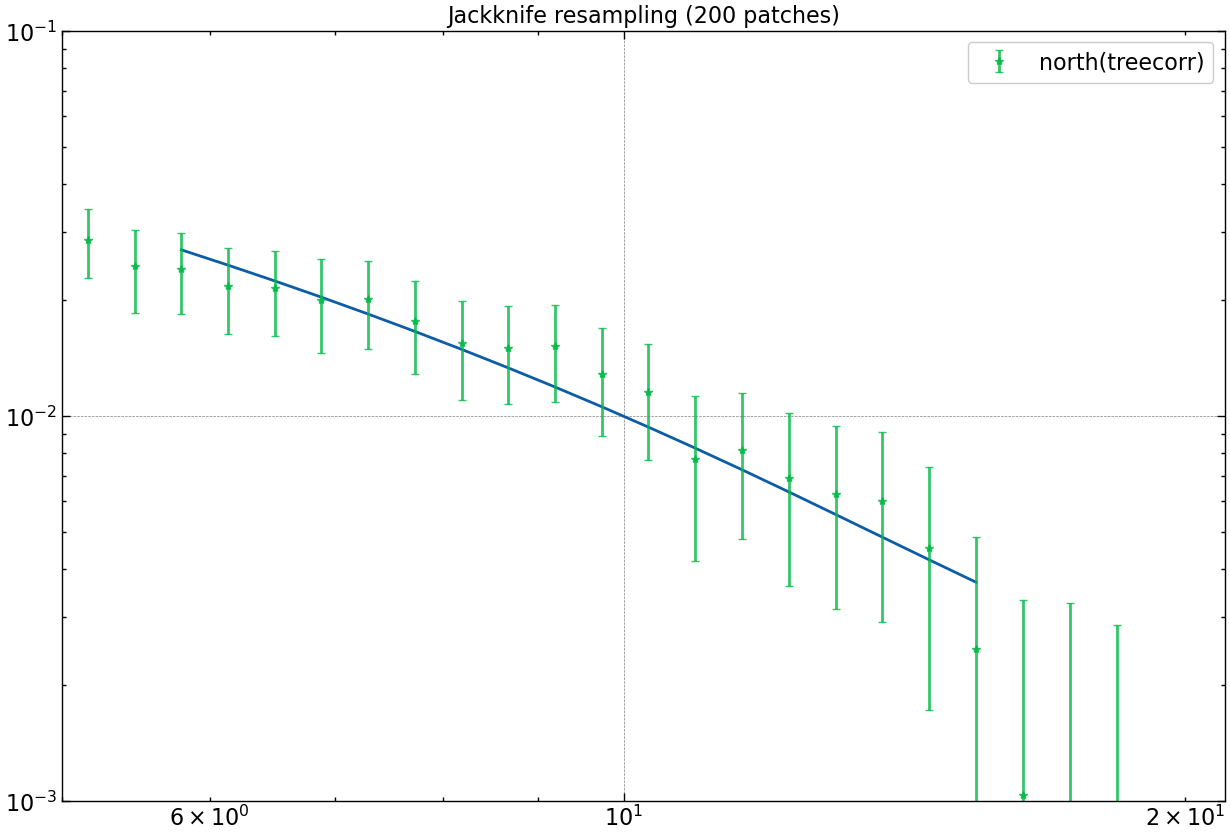

[2.37025629]
[5.61811487]


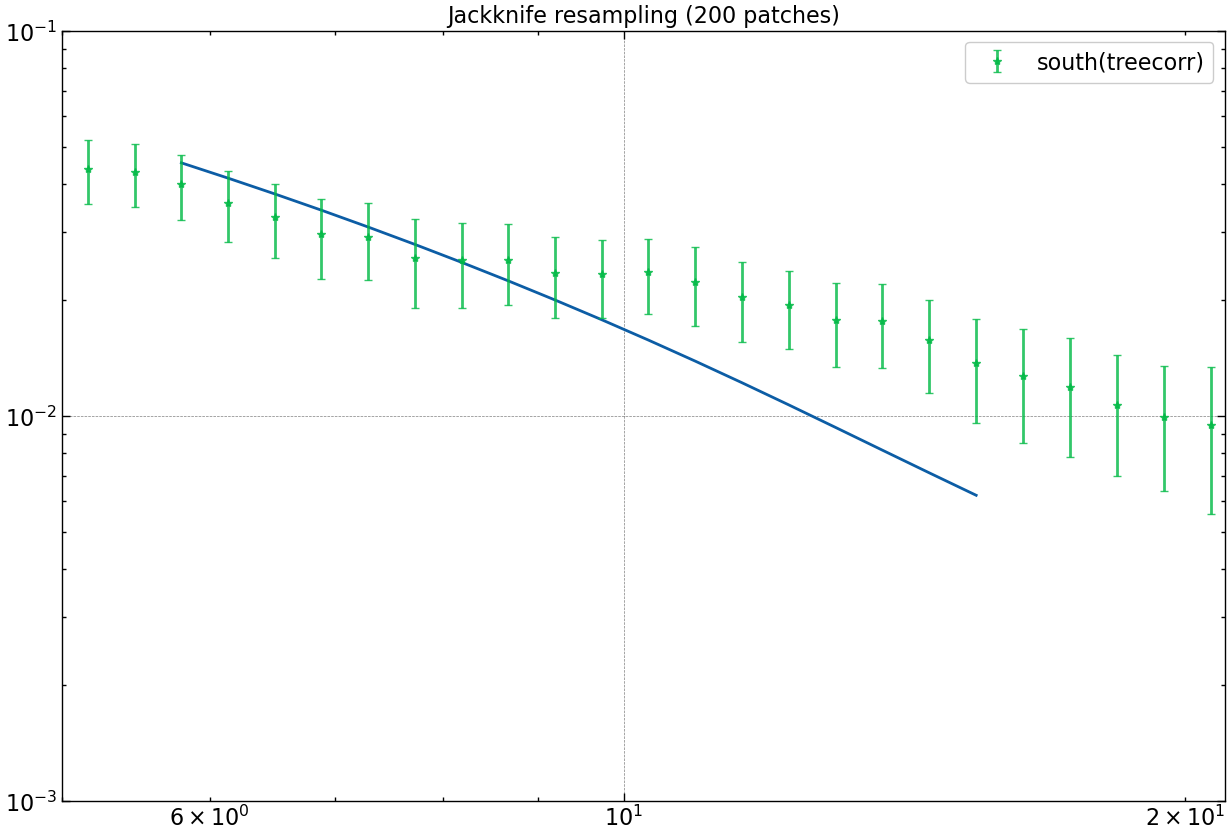

In [ ]:
for file in files_jackknife_200:
    fig, ax = plt.subplots(figsize=(15,10))

    dat = np.load(file)
    name = os.path.basename(file)
    name = name.replace('.npy','')
    name = name.split('_')[1] + '(' + name.split('_')[0] + ')'
    ax.set_title('Jackknife resampling (200 patches)')
    mask_data= (dat[0]<15.9) & (dat[0]>5.6)
    popt,pcov = cf(wfunc,dat[0][mask_data],dat[1][mask_data])
    print(np.sqrt(popt))
    ax.plot(dat[0][mask_data],wfunc(dat[0][mask_data],*popt))
    ax.errorbar(dat[0],dat[1],yerr=dat[2],label=name,marker='*',linestyle='None',capsize=3,alpha=0.8)
    plt.legend()
    print(popt)
    plt.xscale('log')
    plt.yscale('log')
    plt.ylim(0.001,0.1)
    plt.xlim(5,21)
    plt.show()

In [ ]:
files_jackknife = [file for file in files if  'jackknife'  in file and 'corrfunc' in file]
w_estimates_south = np.load(files_jackknife[0])[:,1]
w_estimates_north = np.load(files_jackknife[1])[:,1]
w_estimates_full = np.load(files_jackknife[-1])[:,1]

In [ ]:
# for i in range(w_estimates_north.shape[1]):
#     plt.hist(w_estimates_south[:,i],bins=20)
#     #plt.show()

In [ ]:
x_mean_south= np.mean(w_estimates_south,axis=0)
x_mean_north= np.mean(w_estimates_north,axis=0)
x_mean_full = np.mean(w_estimates_full,axis=0)
from matplotlib.colors import LogNorm

C_jk_north=199/200*((w_estimates_north- x_mean_north).T@(w_estimates_north- x_mean_north))
C_jk_south=199/200*((w_estimates_south- x_mean_south).T@(w_estimates_south- x_mean_south))
C_jk_full = 199/200*((w_estimates_full - x_mean_full).T@(w_estimates_full - x_mean_full))
sigma_jk_north=np.sqrt(np.diag(C_jk_north))
sigma_jk_south=np.sqrt(np.diag(C_jk_south))
sigma_jk_full=np.sqrt(np.diag(C_jk_full))

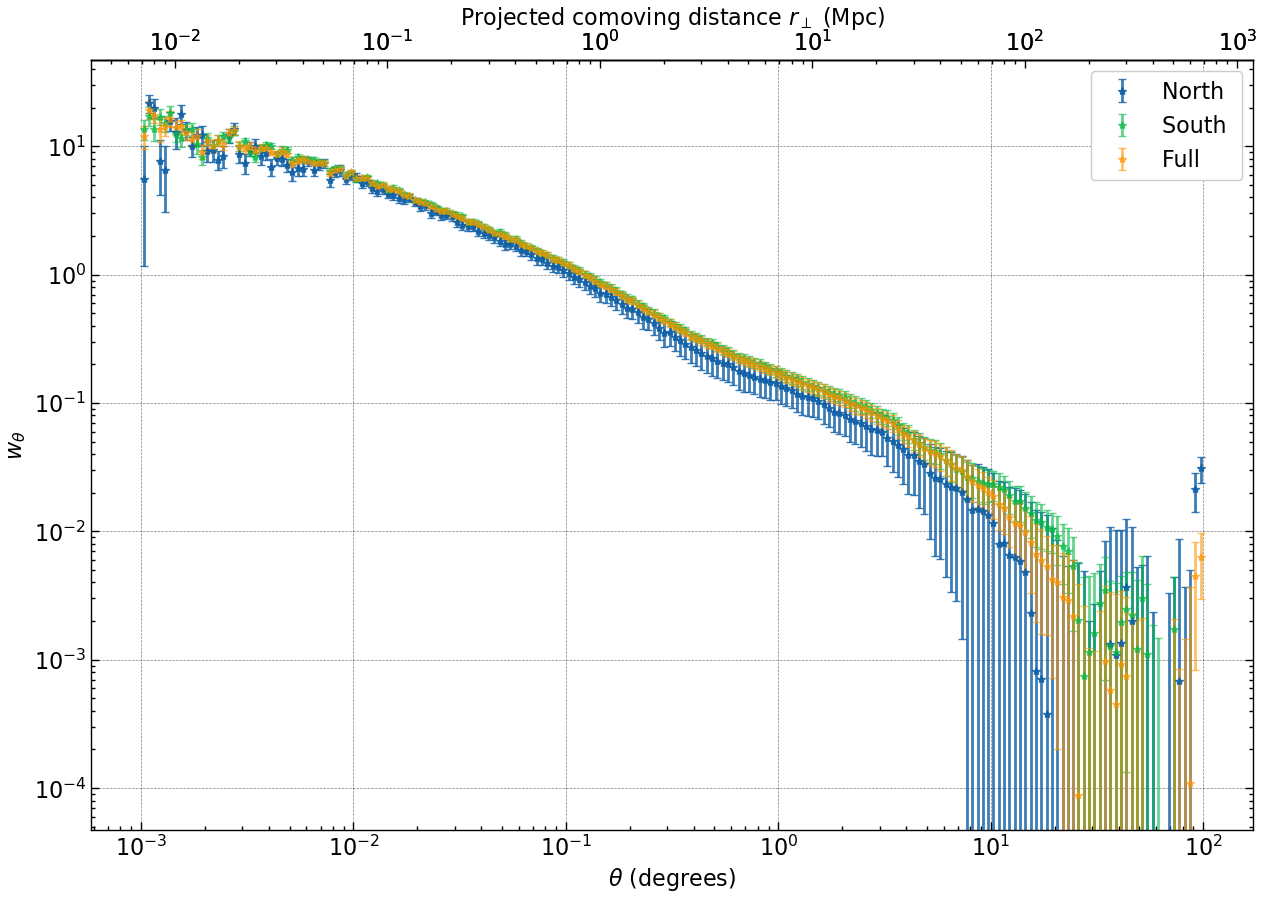

In [ ]:
w_theta_north = np.load('/user/animesh.sah/w_theta_results/corrfunc_north_0.001_to_100.npy')
w_theta_south = np.load('/user/animesh.sah/w_theta_results/corrfunc_south_0.001_to_100.npy')
w_theta_full = np.load('/user/animesh.sah/w_theta_results/corrfunc_full_0.001_to_100.npy')

fig,ax = plt.subplots(figsize=(15,10))
ax.errorbar(w_theta_north[0], w_theta_north[1], yerr=sigma_jk_north,ls='None',marker='*',capsize=3,label = 'North ',alpha=0.8)
ax.errorbar(w_theta_south[0], w_theta_south[1], yerr=sigma_jk_south,ls='None',marker='*',capsize=3,label = 'South ',alpha=0.6)
ax.errorbar(w_theta_full[0], w_theta_full[1], yerr=sigma_jk_full,ls='None',marker='*',capsize=3,label = 'Full ',alpha=0.6)

secax = ax.secondary_xaxis('top',
functions=(theta_to_r_dc,r_to_theta_dc))
secax.set_xlabel(r'Projected comoving distance $r_\perp$ (Mpc)')
secax.set_xscale('log')
#ax.vlines(x=r_to_theta(np.array([1,2,3,4,5,6,7,8,9,10])), ymin=1e-8, ymax=2e2, color='r', linestyle='--', label=r'$\theta$ = 0.147 deg')
secax = ax.secondary_xaxis('top', functions=(theta_to_r_dc, r_to_theta_dc))
secax.tick_params(axis='x', which='both', length=0)  # removes the tick marks, keeps labels
ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True)
plt.legend()

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$\theta$ (degrees)')
ax.set_ylabel(r'$w_{\theta}$')
plt.legend()
plt.savefig('w_theta_jackknife_north_south.png')
plt.show()

In [ ]:
files_point = np.sort([file for file in files if  'jackknife'  not in file and 'bootstrap' not in file and  '0.001_to_100' in file and 'corrfunc' in file  and 'full' not in file])
files_point

array(['/user/animesh.sah/w_theta_results/corrfunc_north_0.001_to_100.npy',
       '/user/animesh.sah/w_theta_results/corrfunc_south_0.001_to_100.npy'],
      dtype='<U65')

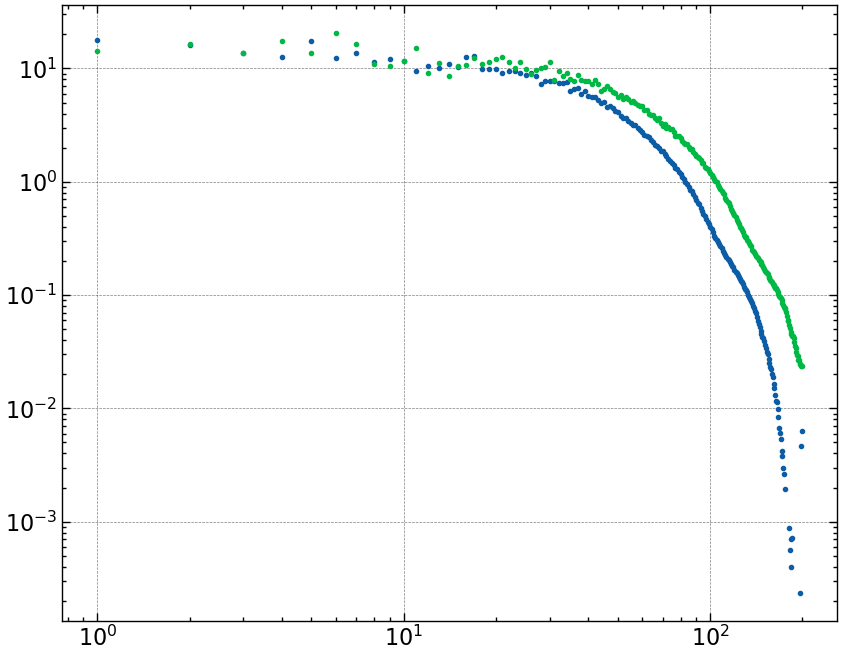

In [ ]:
plt.figure(figsize=(10,8))
plt.loglog(np.mean(w_estimates_south,axis = 0),'.')
plt.loglog(np.mean(w_estimates_north,axis = 0),'.')



Text(0.5, 1.0, 'Jackknife resampling')

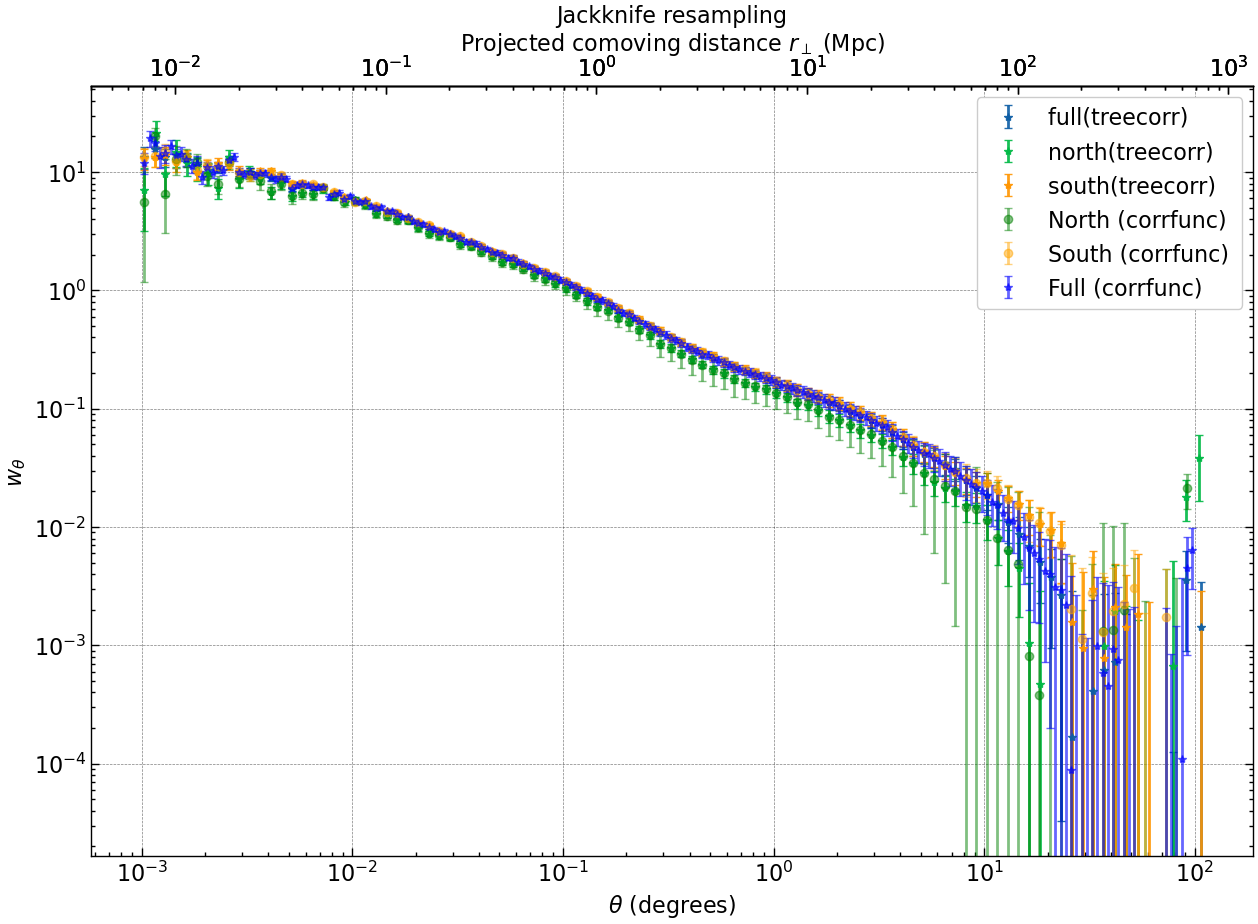

In [ ]:
files= glob.glob('/user/animesh.sah/w_theta_results/*')

files_jackknife_200 = np.sort([file for file in files if  'jackknife'  in file and '200' in file ])

#files_bootstrap = np.sort([file for file in files if  'bootstrap'  in file])
#part = ['north','south','full']


#{patch: [file for file in files if patch in file] for patch in part}

#plt.figure(figsize=(15,10))
fig, ax = plt.subplots(figsize=(15,10))

for file in files_jackknife_200:
    dat = np.load(file)
    name = os.path.basename(file)
    name = name.replace('.npy','')
    name = name.split('_')[1] + '(' + name.split('_')[0] + ')'
    #ax.set_title('Jackknife resampling (200 patches)')
    ax.errorbar(dat[0][::2],dat[1][::2],yerr=dat[2][::2],label=f'{name} ',marker='*',linestyle='None',capsize=3,alpha=0.9)
ax.set_xscale('log')

ax.set_yscale('log')
ax.errorbar(w_theta_north[0][::2], w_theta_north[1][::2], yerr=sigma_jk_north[::2],ls='None',marker='o',color='green',capsize=3,label = 'North (corrfunc) ',alpha=0.5)
ax.errorbar(w_theta_south[0][::2], w_theta_south[1][::2], yerr=sigma_jk_south[::2],ls='None',marker='o',color='orange',capsize=3,label = 'South (corrfunc)',alpha=0.5)
ax.errorbar(w_theta_full[0], w_theta_full[1], yerr=sigma_jk_full,ls='None',marker='*',color='b',capsize=3,alpha=0.6,label ='Full (corrfunc)')

secax = ax.secondary_xaxis('top',
functions=(theta_to_r_dc,r_to_theta_dc))
ax.set_xlabel(r'$\theta$ (degrees)')
ax.set_ylabel(r'$w_{\theta}$')
secax = ax.secondary_xaxis('top',
functions=(theta_to_r_dc,r_to_theta_dc))
secax.set_xlabel(r'Projected comoving distance $r_\perp$ (Mpc)')
secax.set_xscale('log')
#ax.vlines(x=r_to_theta(np.array([1,2,3,4,5,6,7,8,9,10])), ymin=1e-8, ymax=2e2, color='r', linestyle='--', label=r'$\theta$ = 0.147 deg')
secax = ax.secondary_xaxis('top', functions=(theta_to_r_dc, r_to_theta_dc))
secax.tick_params(axis='x', which='both', length=0)  # removes the tick marks, keeps labels
ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True)
plt.legend()
plt.title('Jackknife resampling')

In [ ]:
w_theta

In [ ]:
import pyarrow.parquet as pq
bootstrap = pq.read_table("/user/animesh.sah/DESI_PECVEL/bootstrap_results.parquet")
k = bootstrap.column("bootstrap_test").to_pylist()   # returns list of lists/arrays
lst_boot = np.vstack(k)


mean_lst = np.mean(lst_boot,axis=0)
cov_boot = (1/9999)*((lst_boot- mean_lst).T@(lst_boot- mean_lst))
sigma_boot=np.sqrt(np.diag(cov_boot))
plt.plot(mean_lst,'.')
# lst_boot
# mean=[]
# std=[]
# for i in range(20):
#     plt.hist(lst_boot[:,i],bins=30,edgecolor='k',alpha=0.5)
#     #plt.axvline(W[i],color='r',ls='-.')
#     mean.append(lst_boot[:,i].mean())
#     std.append(lst_boot[:,i].std())
#     plt.show()

FileNotFoundError: /user/animesh.sah/DESI_PECVEL/bootstrap_results.parquet

In [ ]:
north = np.load('/user/animesh.sah/w_theta_results/treecorr_north_none_patches_100_0.001_to_10.npy')
south = np.load('/user/animesh.sah/w_theta_results/treecorr_south_none_patches_100_0.001_to_10.npy')

In [ ]:
w_0_03=np.load('/user/animesh.sah/w_theta_results/corrfunc_north_0.001_to_10_0.03.npy')
w_min0_0234 = np.load('/user/animesh.sah/w_theta_results/corrfunc_north_0.001_to_10_-0.0234.npy')
w_0_04=np.load('/user/animesh.sah/w_theta_results/corrfunc_north_0.001_to_10_0.04.npy')
w_0_0234 = np.load('/user/animesh.sah/w_theta_results/corrfunc_north_0.001_to_10_0.023.npy')


In [ ]:
w_min_0_04 = np.load('/user/animesh.sah/w_theta_results/corrfunc_north_0.001_to_10_min_0.04_v2.npy')
w_0_04 = np.load('/user/animesh.sah/w_theta_results/corrfunc_north_0.001_to_10_0.04_v2.npy')
w_0_0234 = np.load('/user/animesh.sah/w_theta_results/corrfunc_north_0.001_to_10_0.0234_v2.npy')
w_0_01 = np.load('/user/animesh.sah/w_theta_results/corrfunc_north_0.001_to_10_0.01_v2.npy')

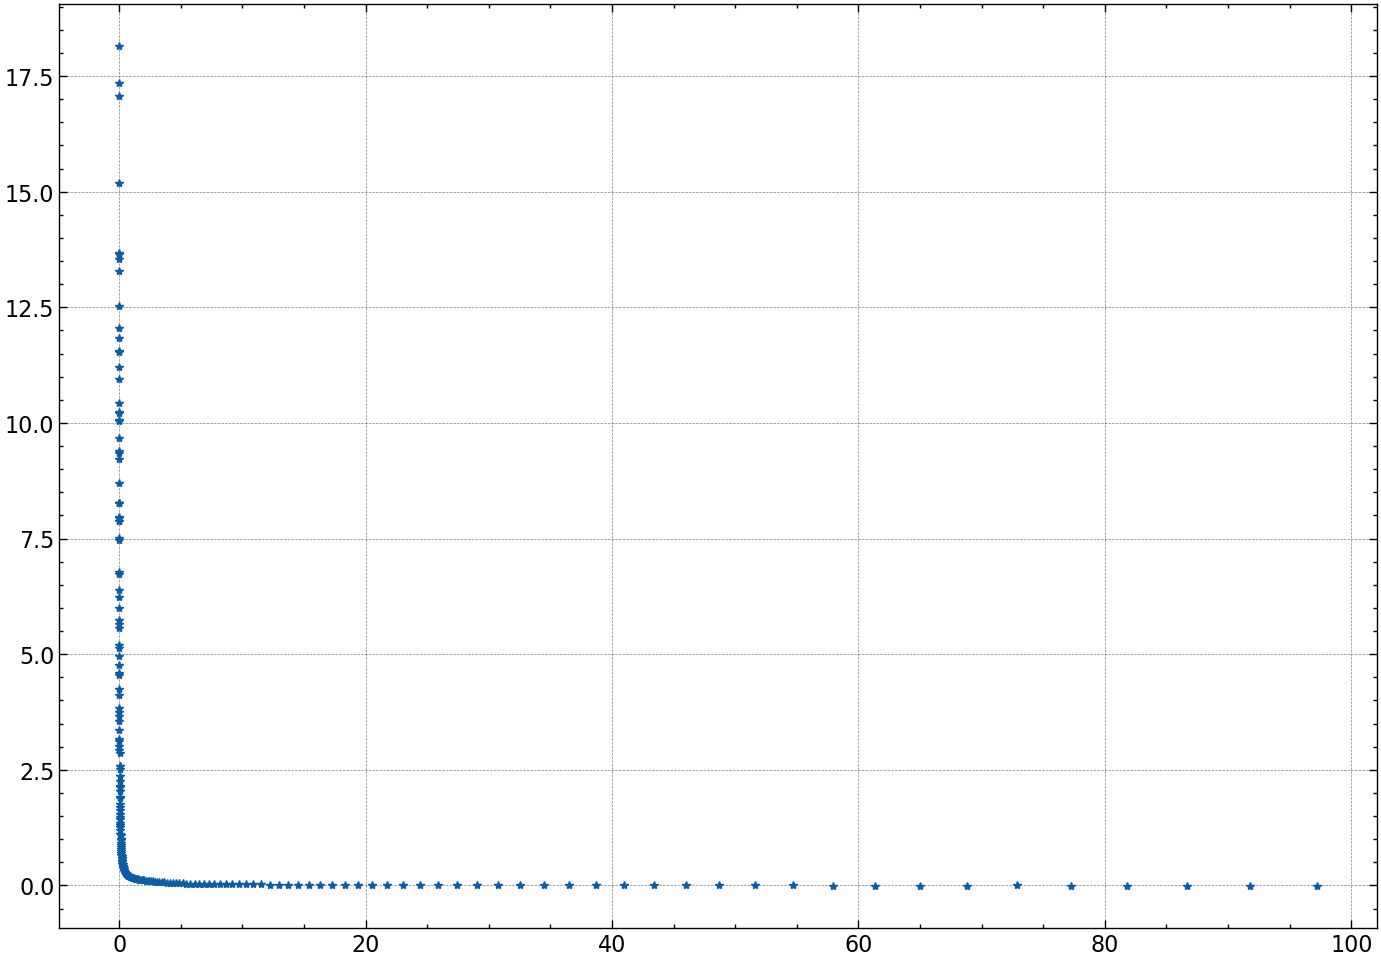

In [ ]:
color = ['k','r','b','g']
fig,ax = plt.subplots(figsize=(17,12))
for file in ['/user/animesh.sah/w_theta_results/corrfunc_south_0.001_to_100.npy']: 
    dat = np.load(file)
    name = os.path.basename(file)
    name = name.replace('.npy','')
    name = name.split('_')[1] + '(' + name.split('_')[0] + ')'
    if  'corrfunc' in name:
        ax.plot(dat[0],dat[1],label=name,marker='*',linestyle='None')
    else: 
        ax.plot(dat[0],dat[1],label=name,marker='.',linestyle='None')

In [ ]:
north = np.load('/user/animesh.sah/w_theta_results/corrfunc_north_0.001_to_100.npy')
south = np.load('/user/animesh.sah/w_theta_results/corrfunc_south_0.001_to_100.npy')
north_bestfit = np.load('/user/animesh.sah/DESI_PECVEL/w_theta_minimized.npy')


north_bestfits={}
for i in range(2,8):
    north_bestfits[i] = np.load(f'/user/animesh.sah/DESI_PECVEL/w_theta_minimized_v{i}.npy')

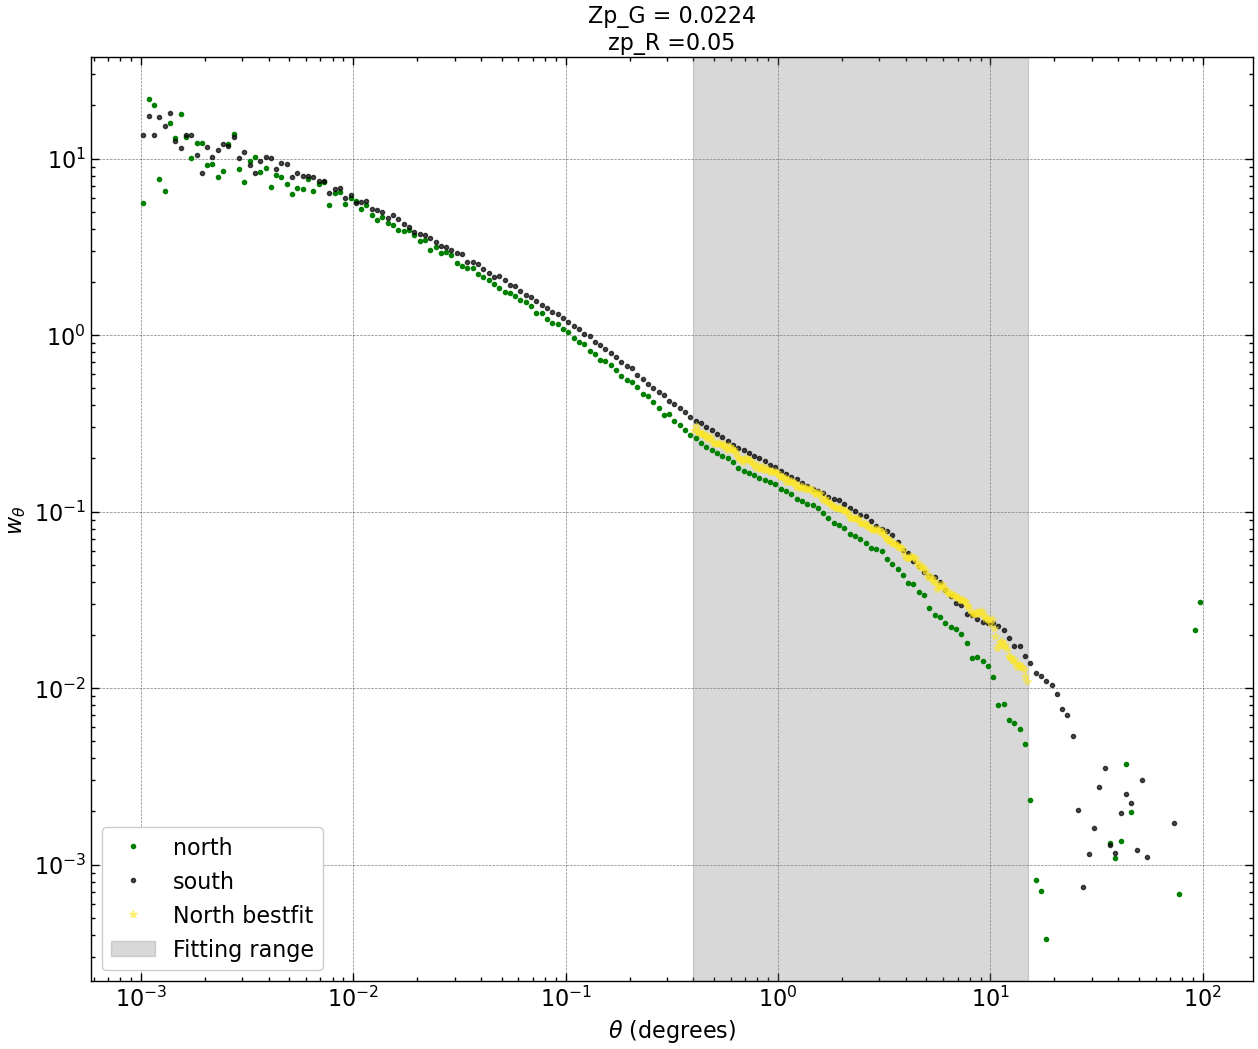

In [ ]:
colors = plt.cm.RdBu(np.linspace(0, 1, 4))

plt.figure(figsize=(15,12))
# plt.plot(w_min_0_04[0],w_min_0_04[1],'*',label='-0.04',color=colors[0],alpha=0.4)
# plt.plot(w_0_01[0],w_0_01[1],'*',label='0.01',color=colors[1],alpha=0.4)
# plt.plot(w_0_0234[0],w_0_0234[1],'*',label='0.0234',color=colors[2],alpha=0.4)

# plt.plot(w_0_04[0],w_0_04[1],'*',label='0.04',color = colors[3],alpha=0.4)
# plt.plot(w_0_0234[0],w_0_0234[1],'*')
# plt.plot(w_0_03[0],w_0_03[1],'*')
plt.xscale('log')
plt.yscale('log')
#dat = np.load(file)
#plt.plot(south[0],south[1],marker='.',linestyle='None',label='south',color='k',alpha=0.7)
plt.plot(north[0],north[1],marker='.',linestyle='None',label='north',color='g')
#plt.plot(north_bestfit[0],north_bestfit[1],marker='*',linestyle='None',label='North bestfit zp')
plt.plot(south[0],south[1],marker='.',linestyle='None',label='south',color='k',alpha=0.7)


colors  = plt.cm.viridis(np.linspace(0,1,6))
for i, (version, data) in enumerate(north_bestfits.items()):
    if i==5:
        plt.plot(data[0], data[1], marker='*', linestyle='None', label=f'North bestfit', color=colors[i], alpha=0.5)
plt.xlabel(r'$\theta$ (degrees)')
plt.ylabel(r'$w_{\theta}$')
plt.title('Zp_G = 0.0224\nzp_R =0.05')
plt.axvspan(xmin=.4, xmax=15, color='gray', alpha=0.3, label='Fitting range')
plt.plot()
plt.legend()

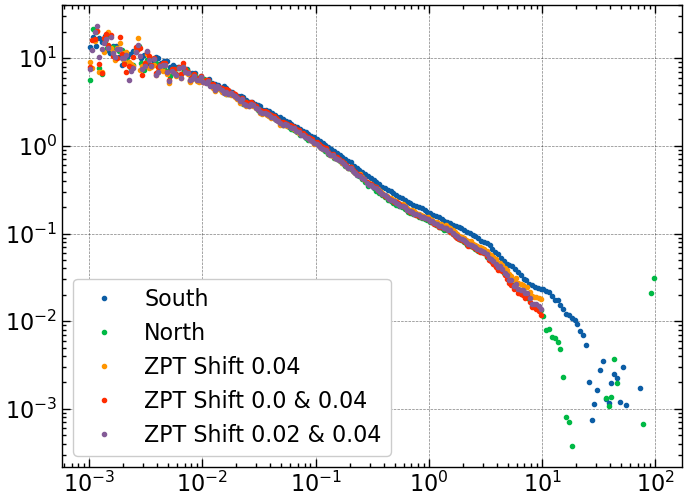

In [ ]:
plt.plot(south[0],south[1],'.',label='South')
plt.plot(north[0],north[1],'.',label='North')

zpt_shift_0_04 = np.load('/user/animesh.sah/DESI_PECVEL/0.04_zpshift.npy')
zpt_shift_0 = np.load('/user/animesh.sah/DESI_PECVEL/zero_zpshift.npy')
zpt_shift_00_0_04 = np.load('/user/animesh.sah/DESI_PECVEL/0.0_0.04_zpshift.npy')
zpt_shift_0_02_0_04 = np.load('/user/animesh.sah/DESI_PECVEL/0.02_0.04_zpshift.npy')
plt.plot(zpt_shift_0_04[0], zpt_shift_0_04[1], '.', label='ZPT Shift 0.04')
#plt.plot(zpt_shift_0[0], zpt_shift_0[1], '.', label='ZPT Shift 0')
plt.plot(zpt_shift_00_0_04[0], zpt_shift_00_0_04[1], '.', label='ZPT Shift 0.0 & 0.04')
plt.plot(zpt_shift_0_02_0_04[0], zpt_shift_0_02_0_04[1], '.', label='ZPT Shift 0.02 & 0.04')
plt.xscale('log')
plt.yscale('log')
plt.legend()


In [ ]:
w_theta= np.load('/user/animesh.sah/w_theta_results/corrfunc_north_0.001_to_10.npy')


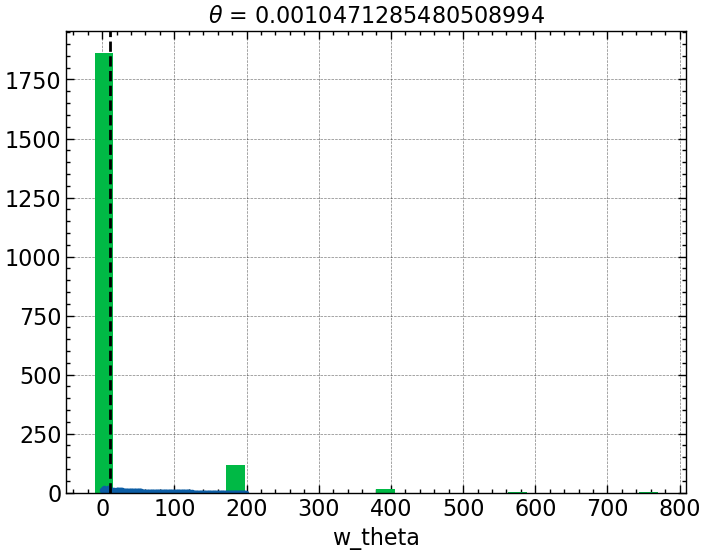

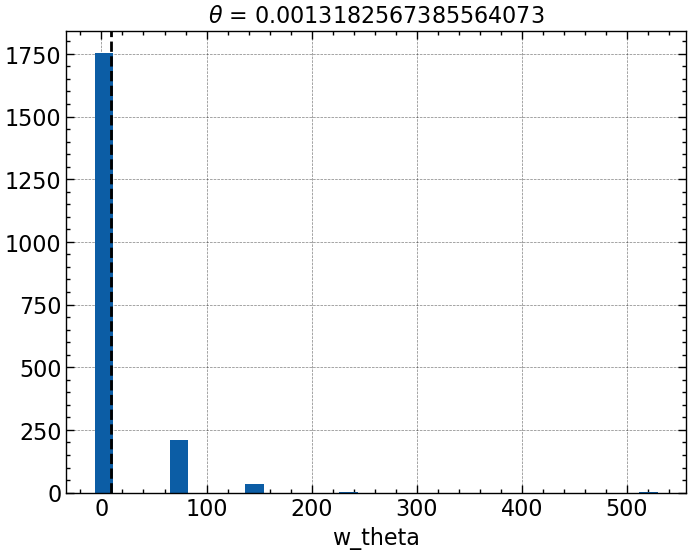

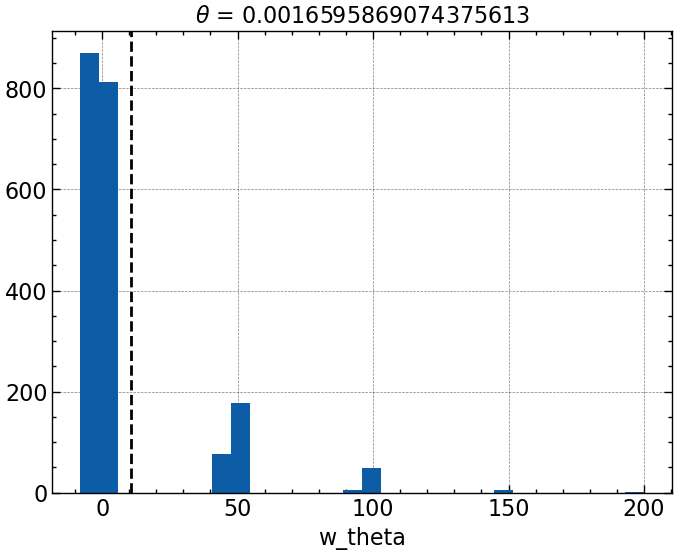

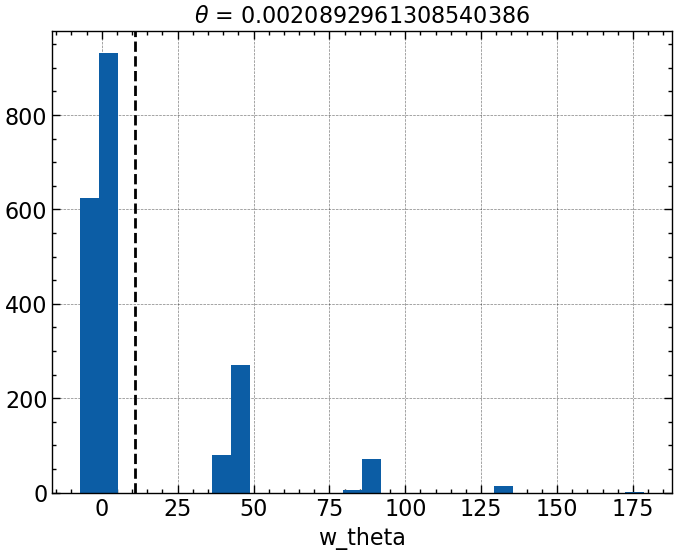

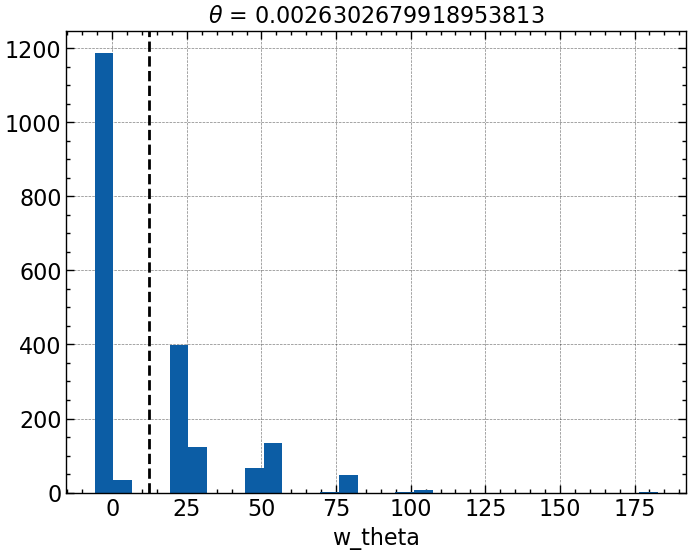

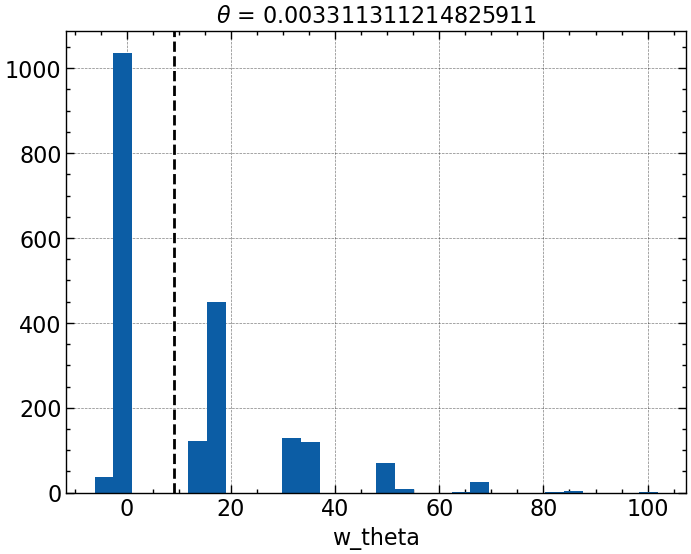

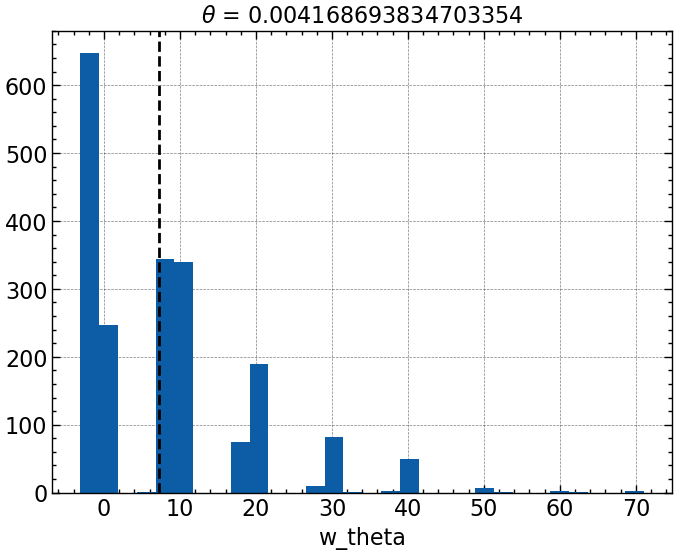

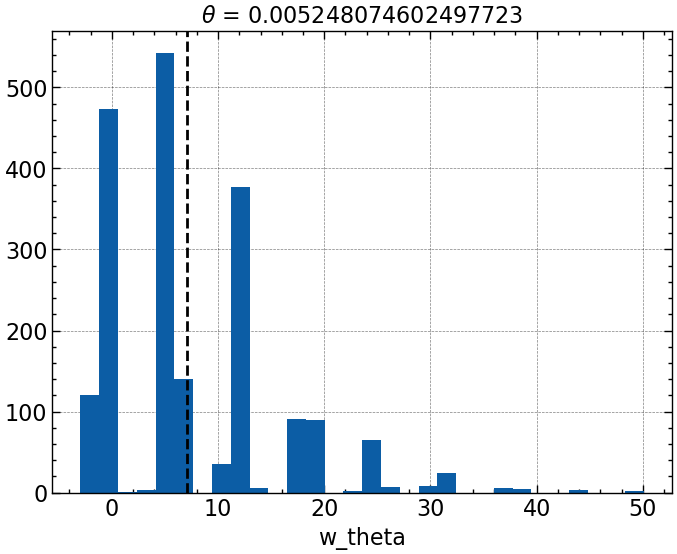

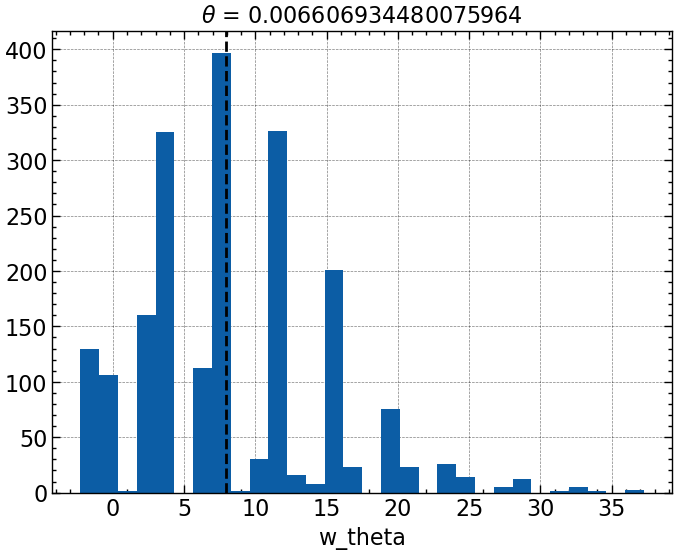

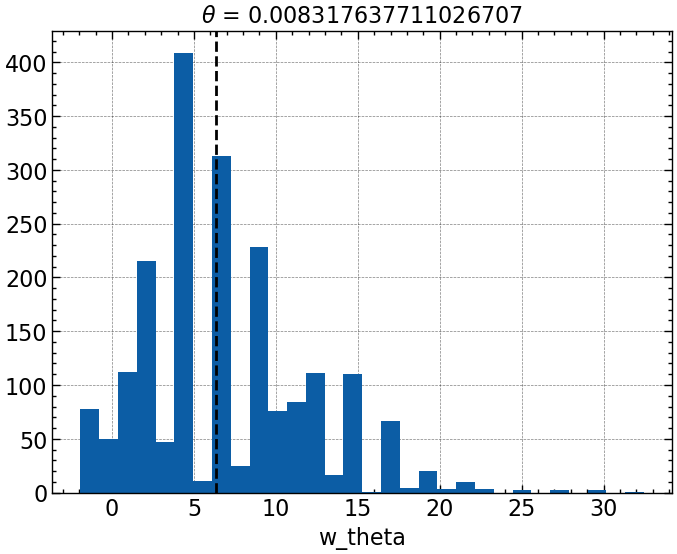

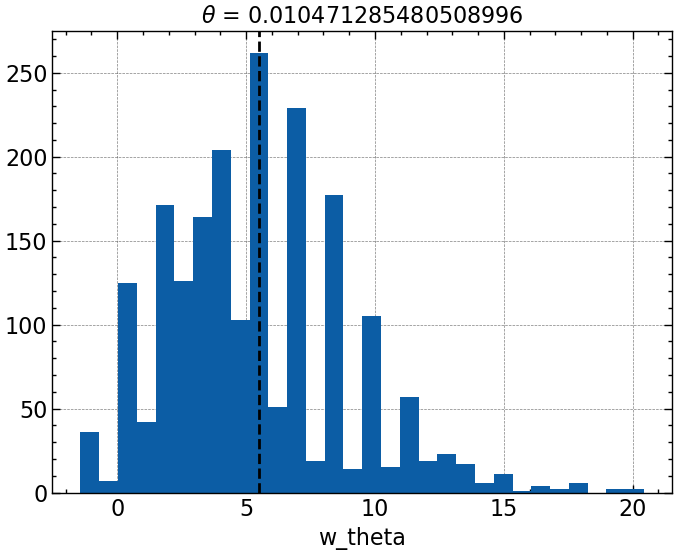

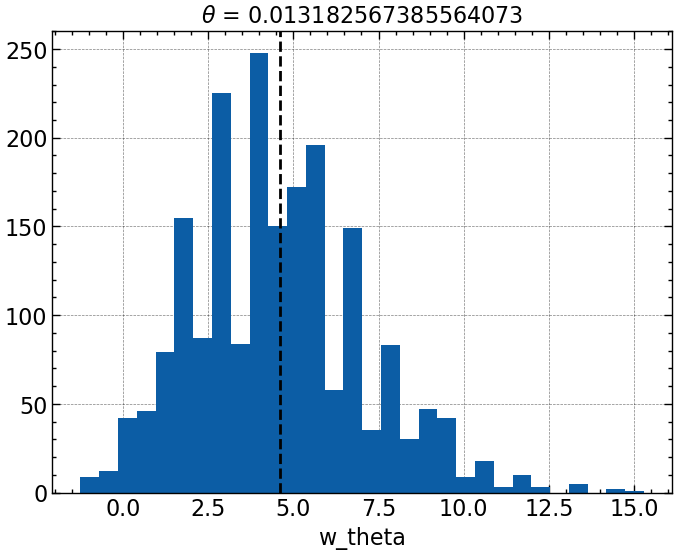

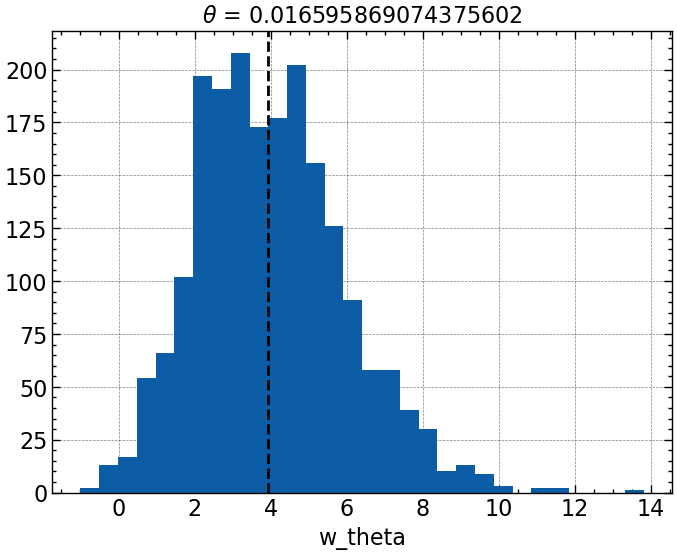

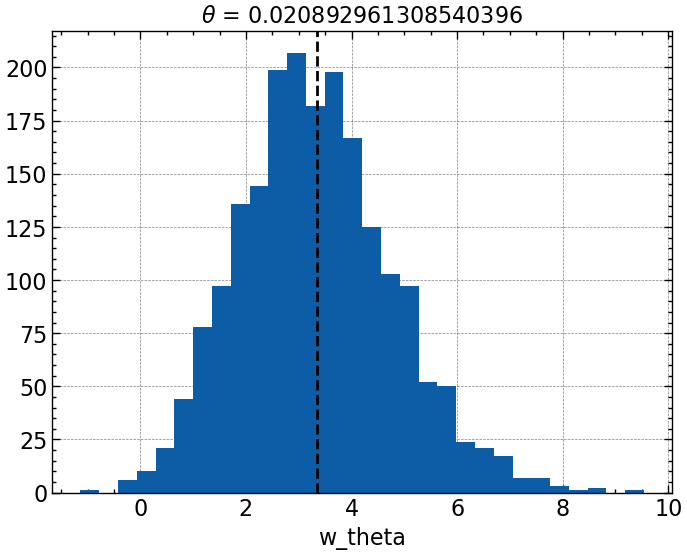

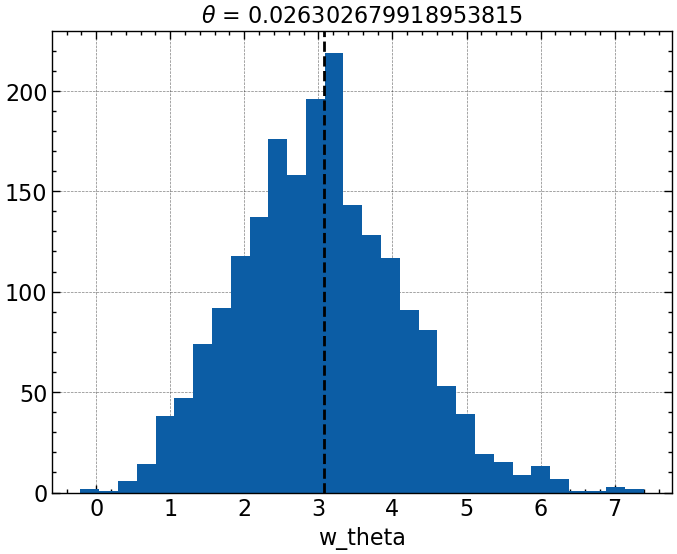

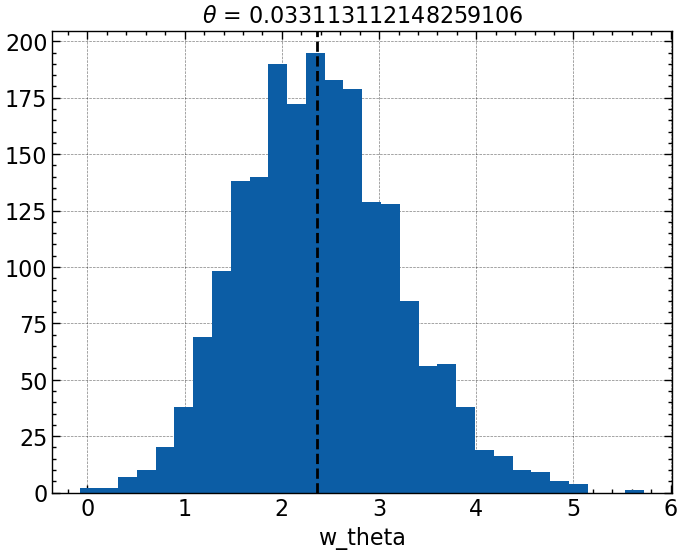

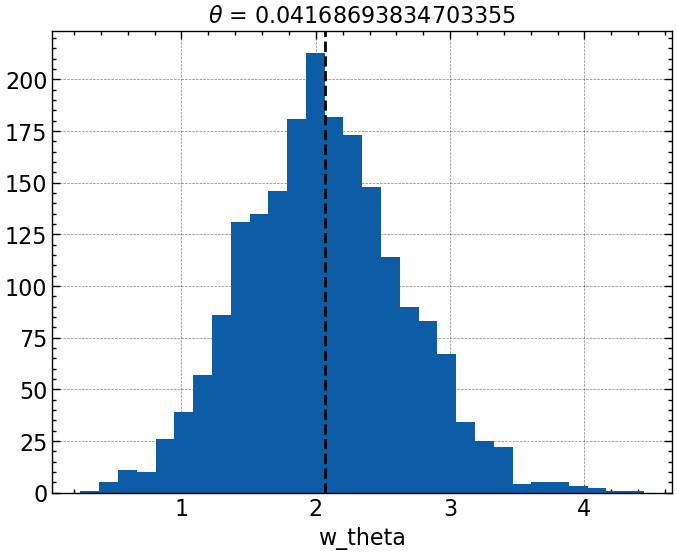

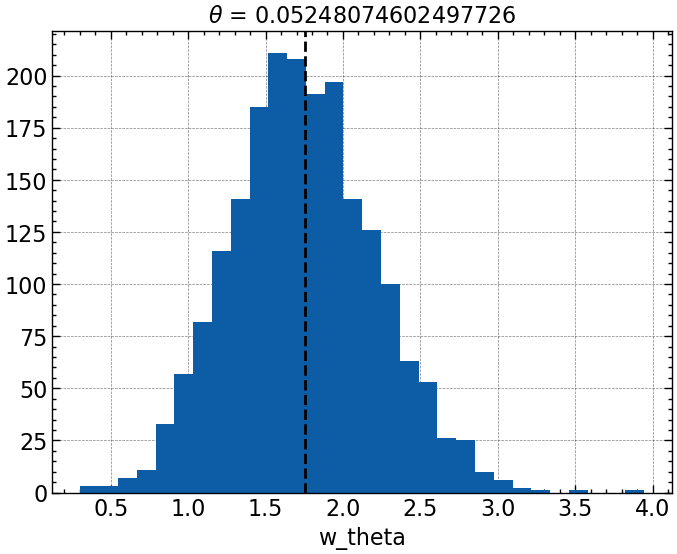

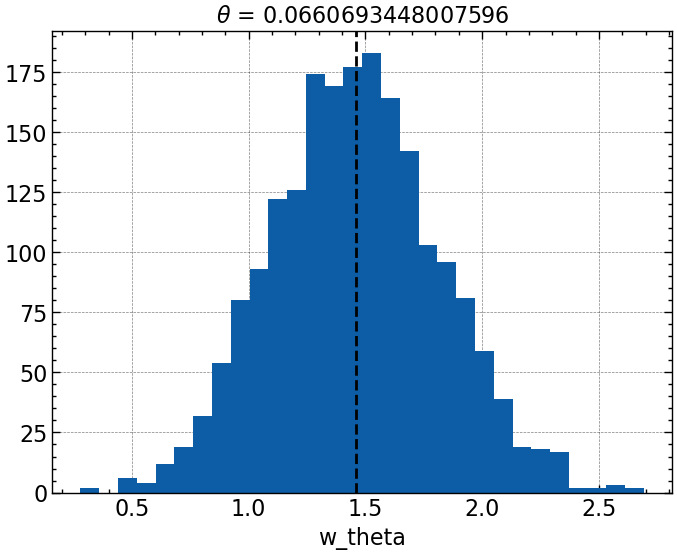

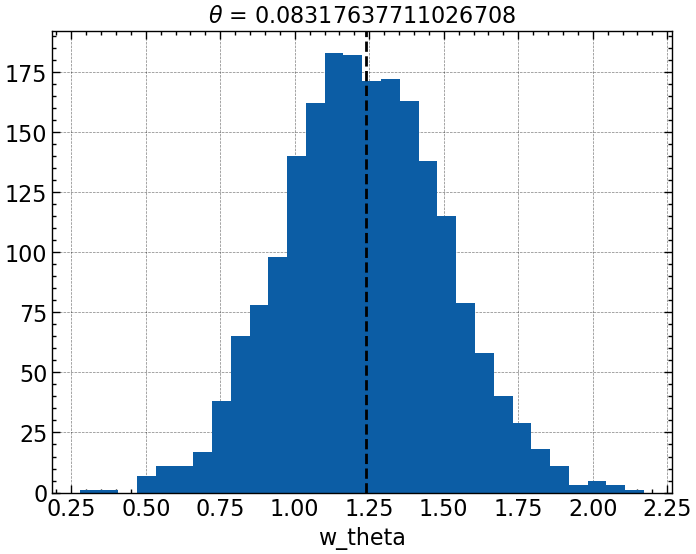

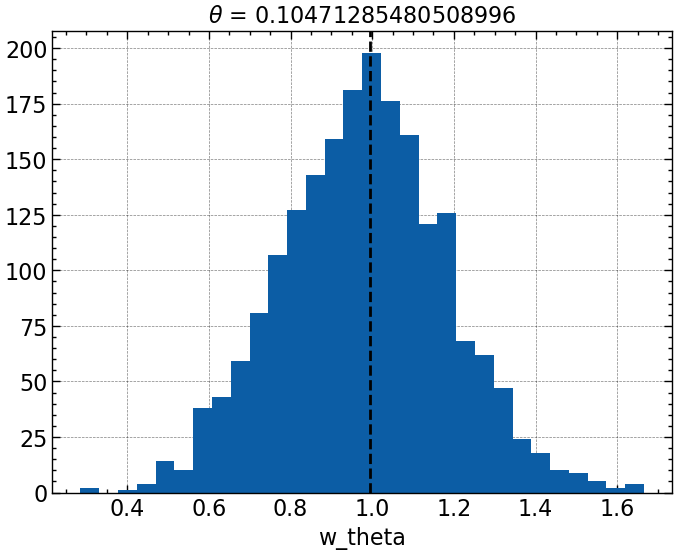

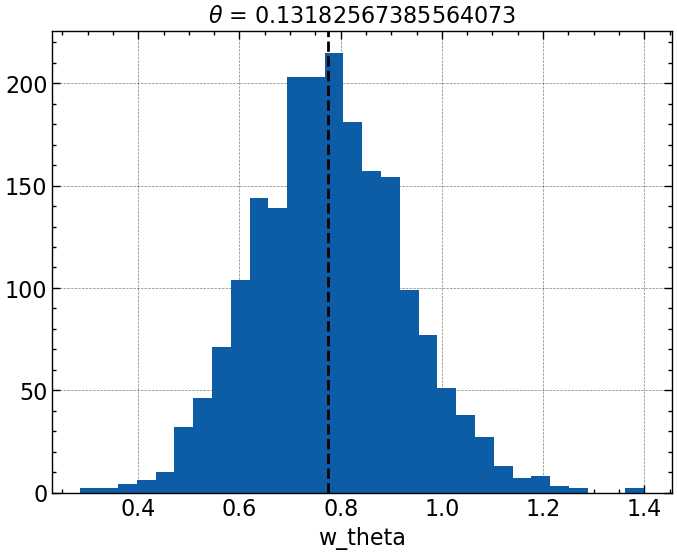

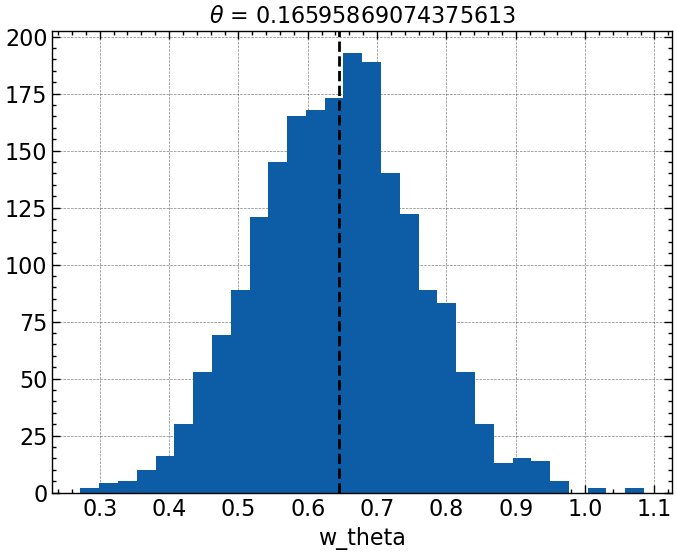

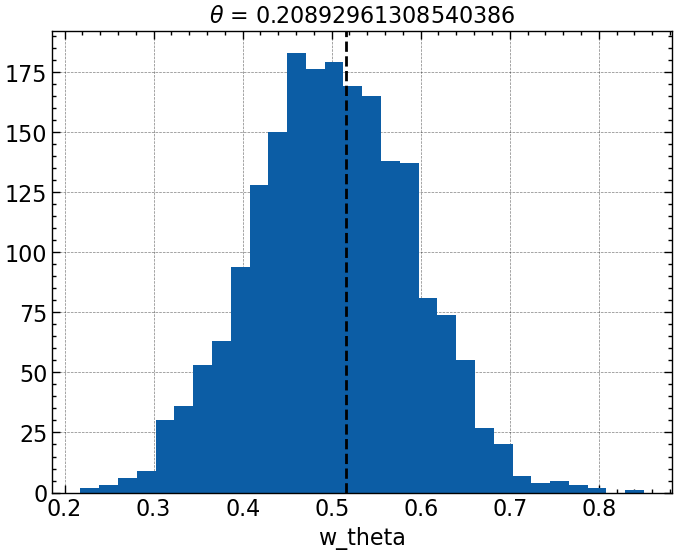

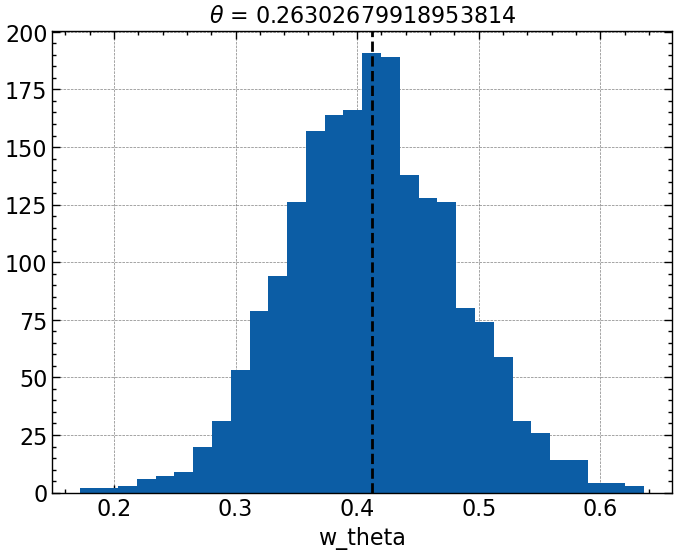

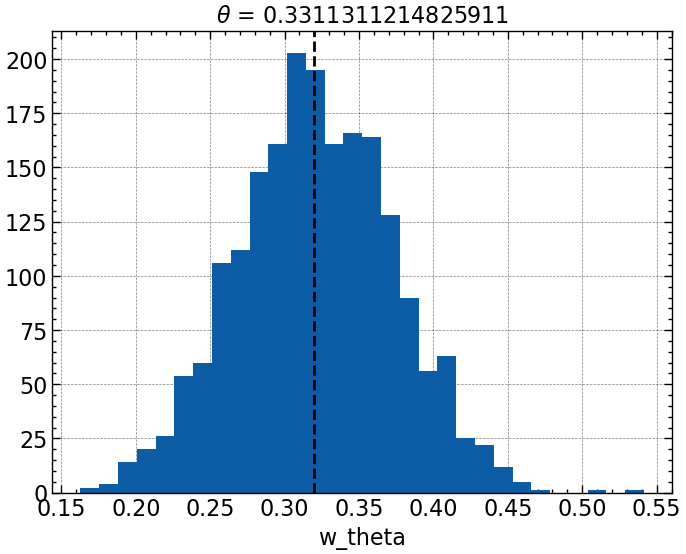

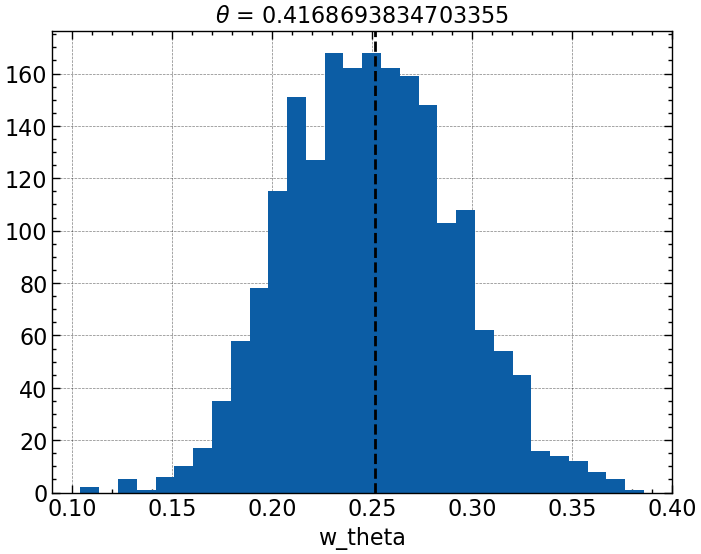

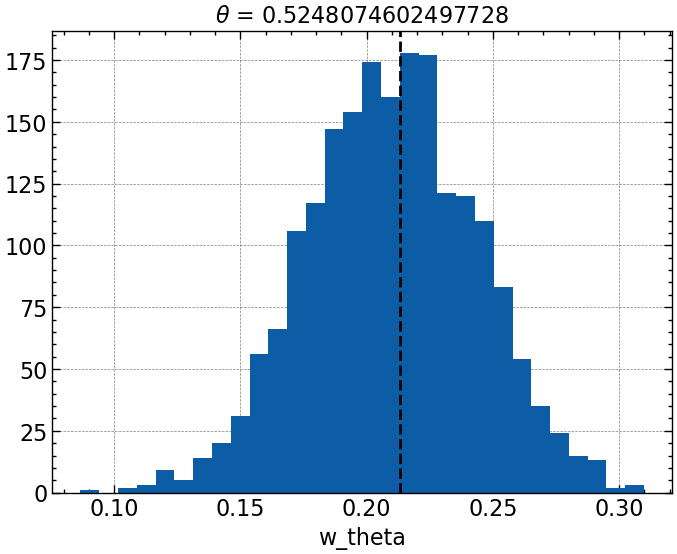

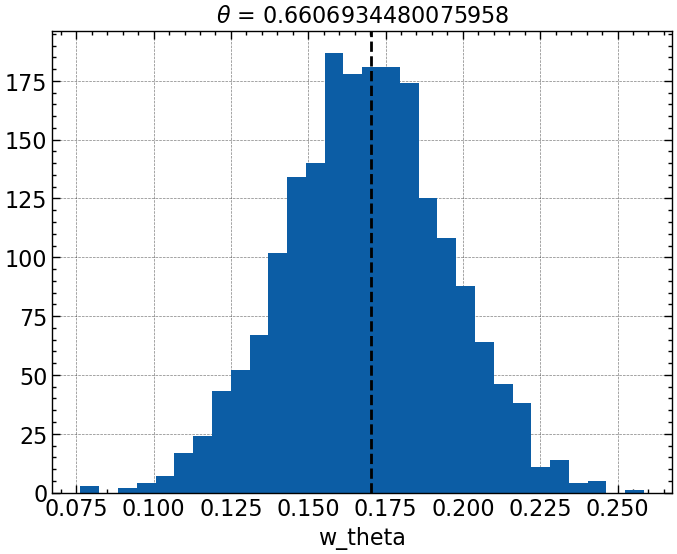

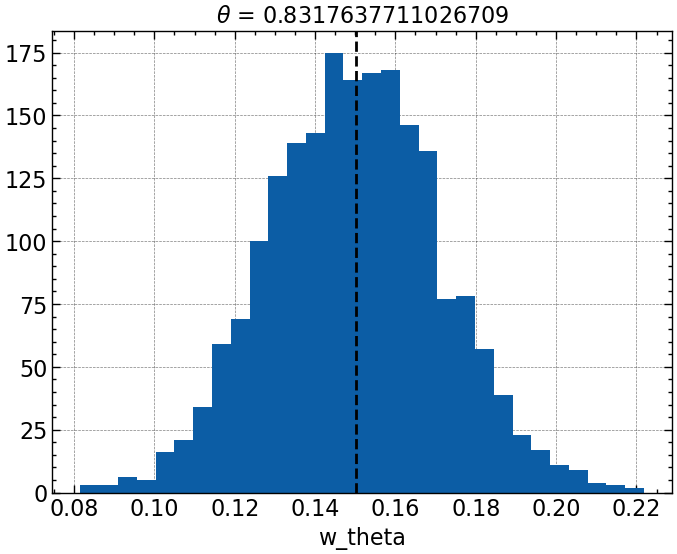

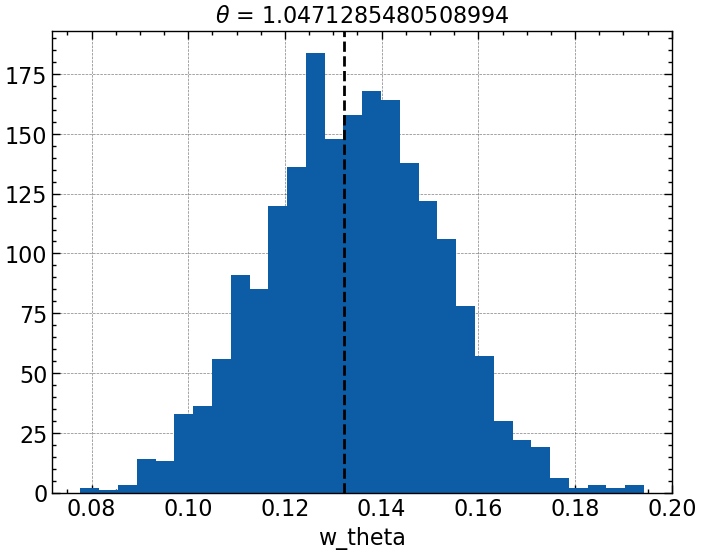

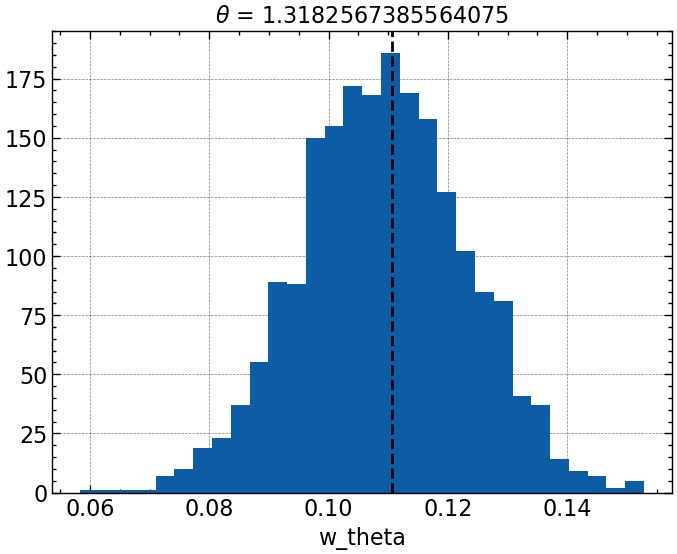

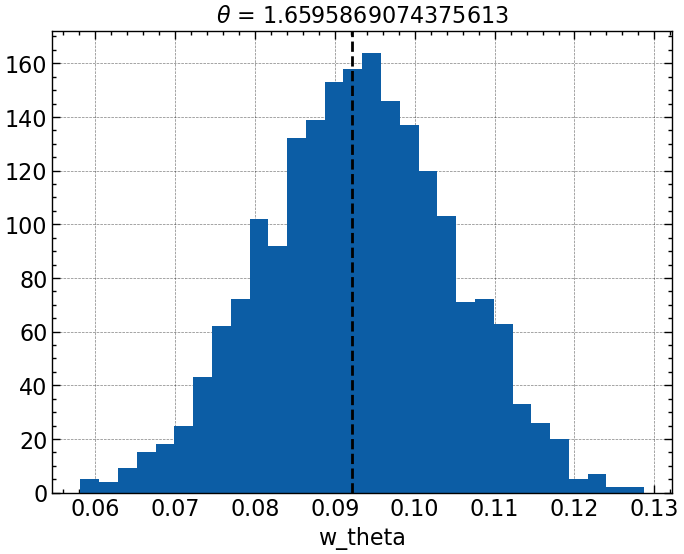

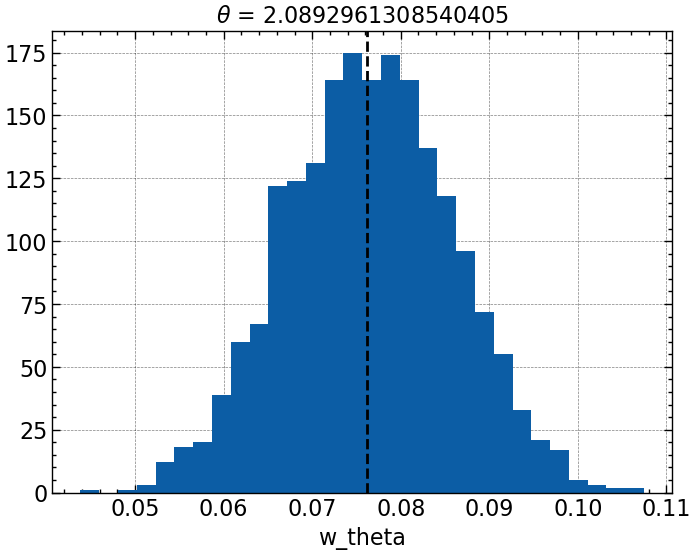

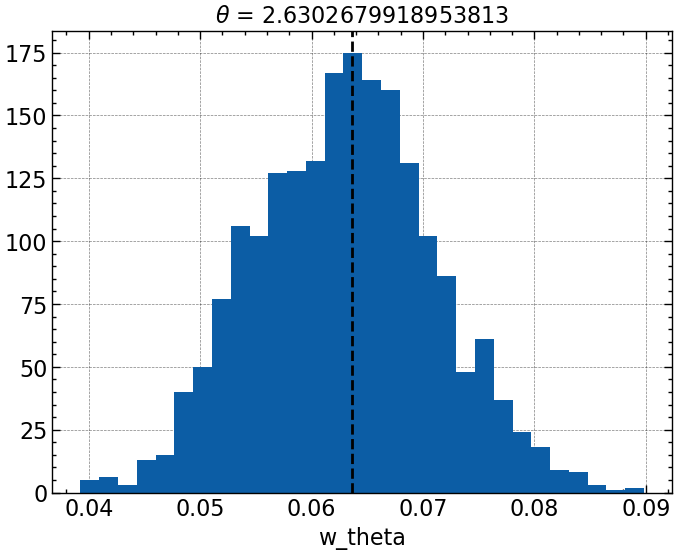

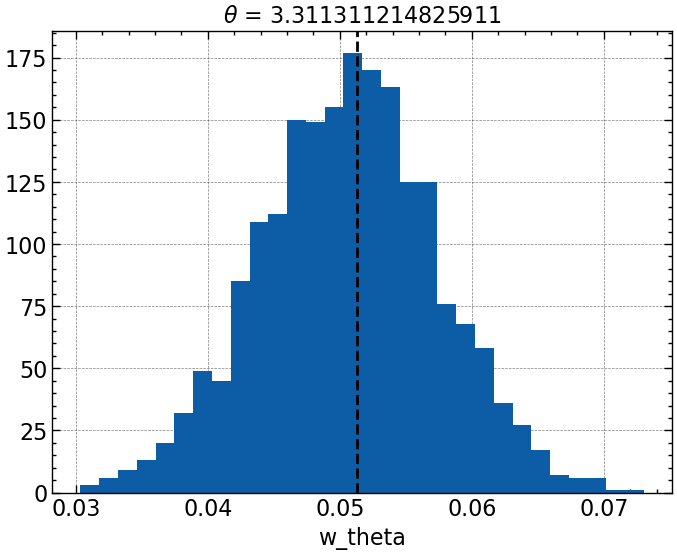

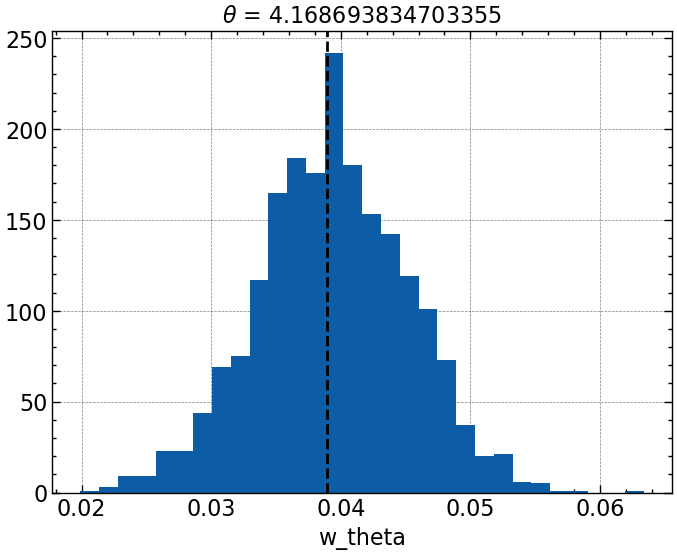

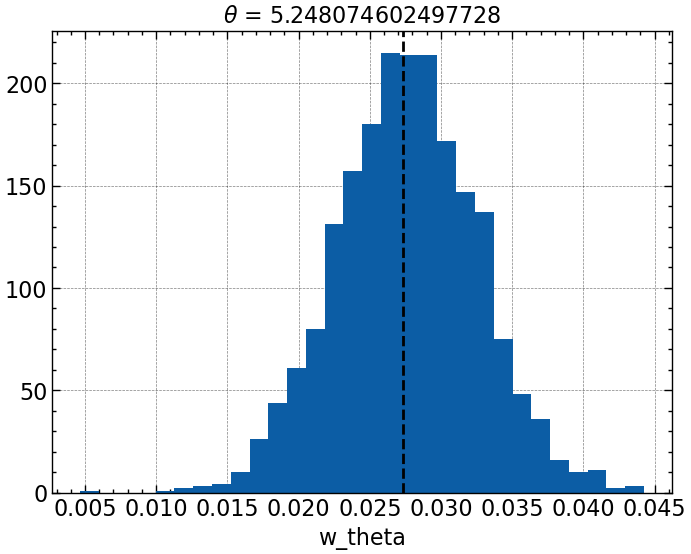

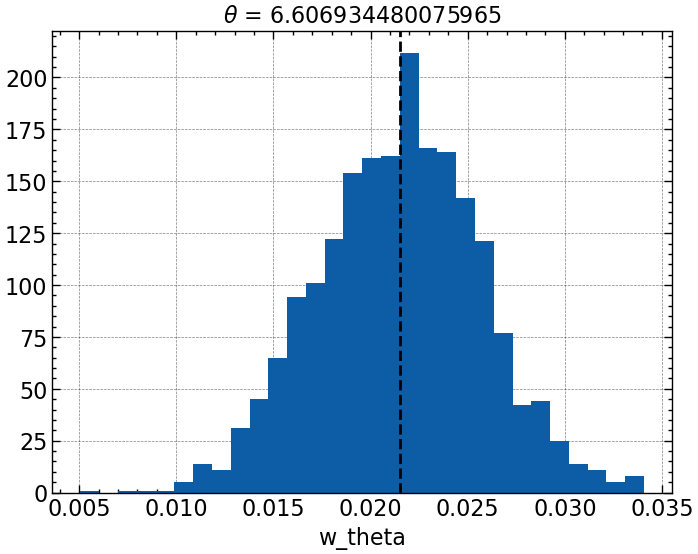

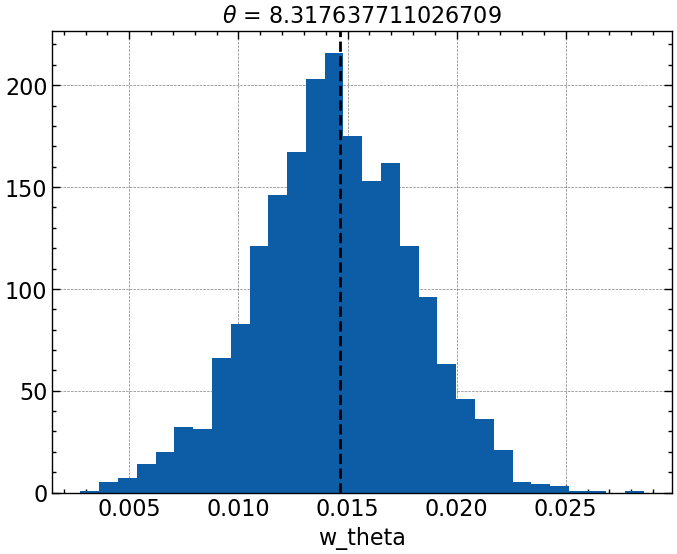

In [ ]:
north=np.load('/user/animesh.sah/w_theta_results/corrfunc_north_bootstrap__num_bootstrap_2000_0.001_to_10_v2.npy')
th=np.logspace(np.log10(0.001), np.log10(10), 200+1 )
plt.plot(np.mean(north,axis=0),'.')
for i in range(1,north.shape[1],5):
    plt.hist(north[:,i],bins=30)
    plt.title(r'$\theta$ = '+str(th[i]))
    plt.axvline(w_theta[1][i],color='k',ls='--')
    plt.xlabel('w_theta')
    plt.show()

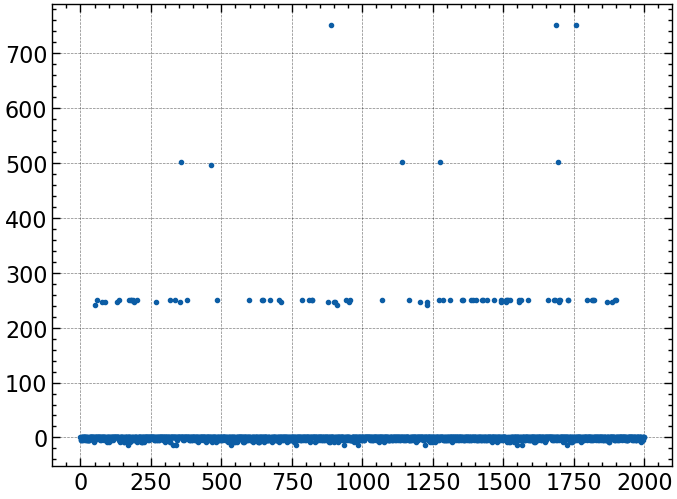

In [ ]:
plt.plot(north[:,0],'.')

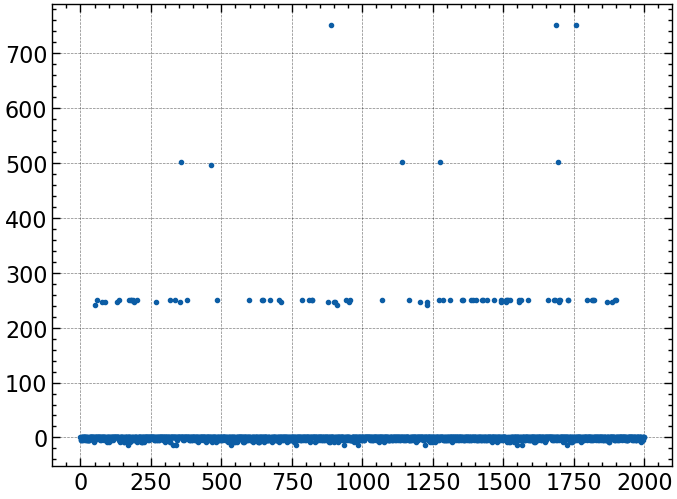

In [ ]:
plt.plot(north[:,0],'.')

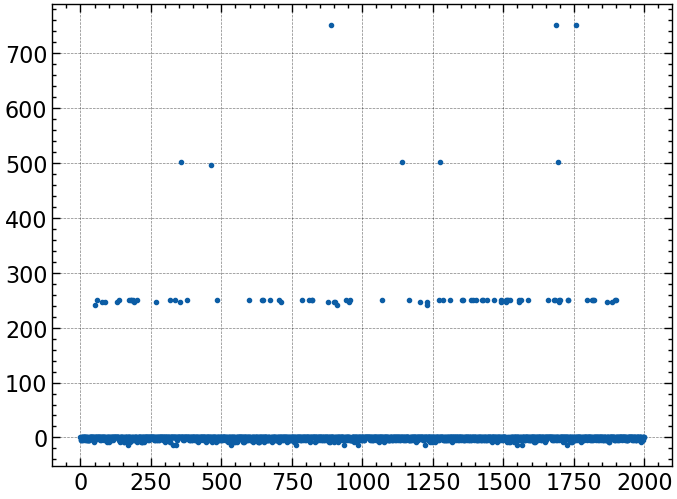

In [ ]:
plt.plot(north[:,0],'.')

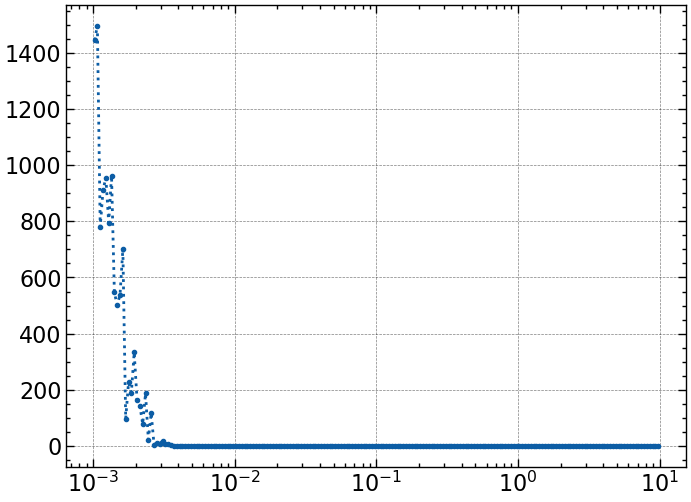

In [ ]:

plt.plot((th[1:]+th[:-1])/2,[np.count_nonzero(north[:,i]==1) for i in range(north.shape[1])],'.:')
#plt.yscale('log')
plt.xscale('log')

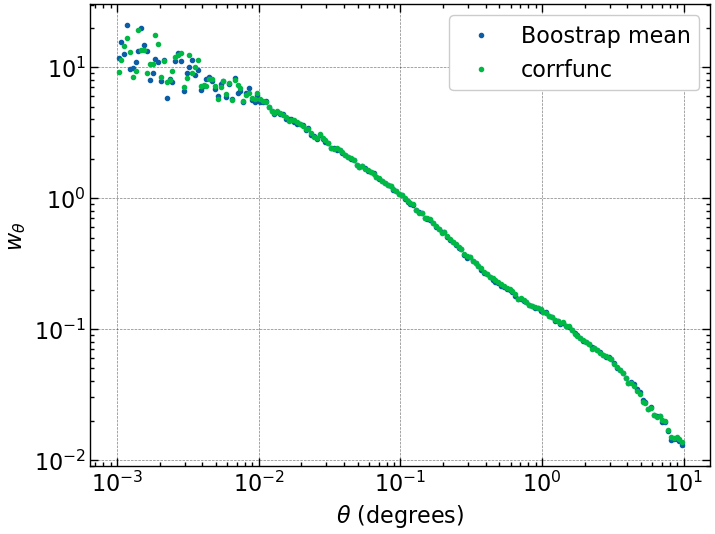

In [ ]:
plt.plot(w_theta[0],north.mean(axis=0),'.',label='Boostrap mean')
plt.plot(w_theta[0],w_theta[1],'.',label='corrfunc')
plt.xscale('log')
plt.yscale('log')
plt.xlabel(r'$\theta$ (degrees)')
plt.ylabel(r'$w_{\theta}$')
plt.legend()

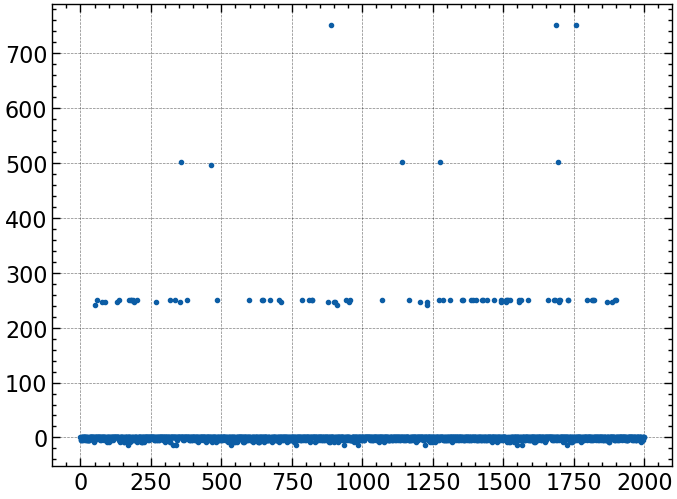

In [ ]:
plt.plot(north[:,0],'.')

In [ ]:
np.count_nonzero(north[0]==1)

3

In [ ]:
w_theta_north_by5 = np.load('/user/animesh.sah/w_theta_results/corrfunc_north_bootstrap_num_bootstrap_2000_0.001_to_1_test_by5.npy')
w_theta_north_by10 = np.load('/user/animesh.sah/w_theta_results/corrfunc_north_bootstrap_num_bootstrap_2000_0.001_to_1_test_by10.npy')
w_theta_north_by2 = np.load('/user/animesh.sah/w_theta_results/corrfunc_north_bootstrap_num_bootstrap_2000_0.001_to_1_test_by2.npy')
w_theta_north_by1 = np.load('/user/animesh.sah/w_theta_results/corrfunc_north_bootstrap_num_bootstrap_2000_0.001_to_1_test_by1.npy')
th = np.logspace(np.log10(0.001), np.log10(1), 200+1 )

(0.0009, 0.01)

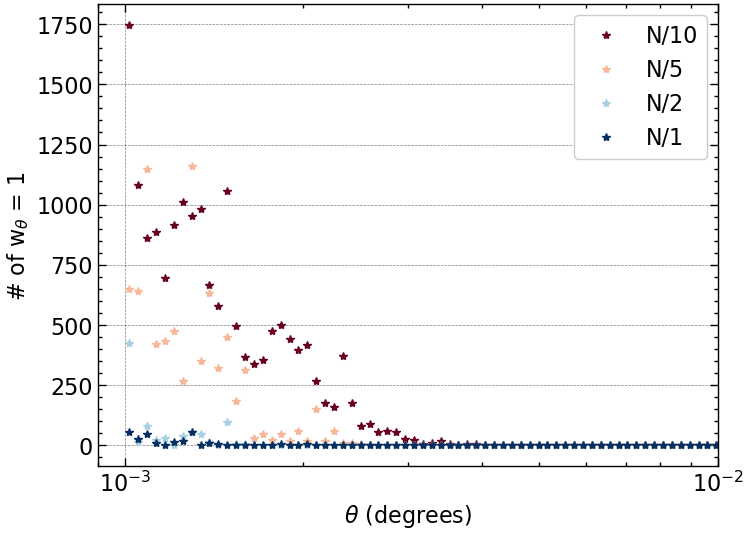

In [ ]:
colors = plt.cm.RdBu(np.linspace(0, 1, 4))
plt.plot((th[1:]+th[:-1])/2,[np.count_nonzero(w_theta_north_by10[:,i]==1) for i in range(w_theta_north_by10.shape[1])],'*',color=colors[0],label='N/10')

plt.plot((th[1:]+th[:-1])/2,[np.count_nonzero(w_theta_north_by5[:,i]==1) for i in range(w_theta_north_by5.shape[1])],'*',color=colors[1],label='N/5')
plt.plot((th[1:]+th[:-1])/2,[np.count_nonzero(w_theta_north_by2[:,i]==1) for i in range(w_theta_north_by2.shape[1])],'*',color=colors[2],label='N/2')

plt.plot((th[1:]+th[:-1])/2,[np.count_nonzero(w_theta_north_by1[:,i]==1) for i in range(w_theta_north_by1.shape[1])],'*',color=colors[3],label='N/1')

plt.xscale('log')
plt.xlabel(r'$\theta$ (degrees)')
plt.ylabel(r'# of w$_\theta$ = 1')
plt.legend()
plt.xlim(9e-4,1e-2)
#plt.title('For N/5')
#plt.yscale('log')

In [ ]:
len(w_theta_north_by10[:,i])

2000

(0.0009, 0.05)

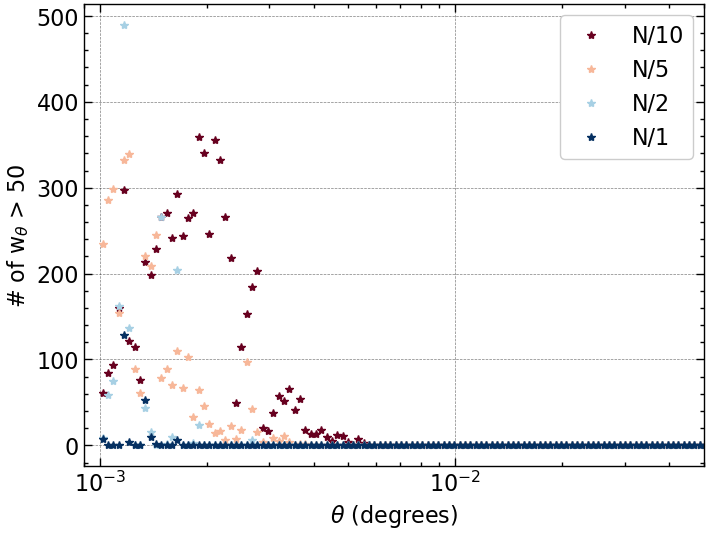

In [ ]:
colors = plt.cm.RdBu(np.linspace(0, 1, 4))
plt.plot((th[1:]+th[:-1])/2,[np.count_nonzero(w_theta_north_by10[:,i]>50) for i in range(w_theta_north_by10.shape[1])],'*',color=colors[0],label='N/10')

plt.plot((th[1:]+th[:-1])/2,[np.count_nonzero(w_theta_north_by5[:,i]>50) for i in range(w_theta_north_by5.shape[1])],'*',color=colors[1],label='N/5')
plt.plot((th[1:]+th[:-1])/2,[np.count_nonzero(w_theta_north_by2[:,i]>50) for i in range(w_theta_north_by2.shape[1])],'*',color=colors[2],label='N/2')

plt.plot((th[1:]+th[:-1])/2,[np.count_nonzero(w_theta_north_by1[:,i]>50) for i in range(w_theta_north_by1.shape[1])],'*',color=colors[3],label='N/1')

plt.xscale('log')
plt.xlabel(r'$\theta$ (degrees)')
plt.ylabel(r'# of w$_\theta$ > 50')
plt.legend()
plt.xlim(9e-4,5e-2)

In [ ]:
import pyccl as ccl

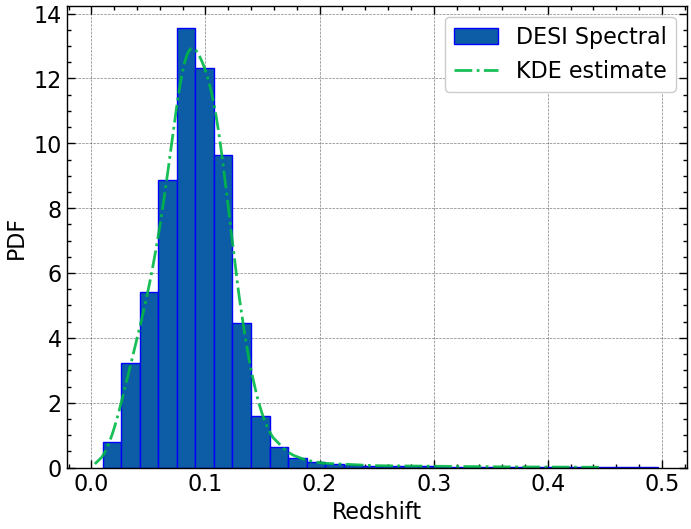

In [ ]:
cosmo_params = dict(
    Omega_c=0.264,  # Cold dark matter density
    Omega_b=0.049,  # Baryon density
    h=0.674,        # Hubble parameter
    sigma8=0.811,    # Power spectrum normalization
    n_s=0.965,       # Spectral index,
    transfer_function="boltzmann_camb"
)


from scipy.stats import gaussian_kde
matched_dr=Table(fitsio.FITS('/user/animesh.sah/DESI_PECVEL/DR_matched.fits')[1].read())
kde = gaussian_kde(matched_dr['Z'],bw_method=0.25)
samples = kde.resample(500).flatten()
samples = np.clip(samples, 0, None)
y_samples=kde.evaluate(samples)
samples_sorted=np.sort(samples)
arg=np.argsort(samples)
y_samples_sorted= y_samples[arg]

plt.hist(matched_dr['Z'],bins=30,edgecolor='blue',label='DESI Spectral',density=True)

plt.plot(samples_sorted,y_samples_sorted,'-.',alpha=0.9,label='KDE estimate')
plt.xlabel('Redshift')
plt.ylabel('PDF')
plt.legend()
z=samples_sorted
n_z=y_samples_sorted
n_z /= np.trapz(y_samples_sorted, samples_sorted)
# linear galaxy bias
bias = 1*np.ones_like(z) #+ 0.5*z

theta = np.logspace(np.log10(1/60), np.log10(3), 40) # degrees
ell = np.arange(2, 4000)
cosmo_lin = ccl.Cosmology(
    **cosmo_params,
    matter_power_spectrum="linear"
)
tr_lin = ccl.NumberCountsTracer(cosmo_lin, dndz=(z, n_z), bias=(z, bias),has_rsd=False)
cl_lin = ccl.angular_cl(cosmo_lin, tr_lin, tr_lin, ell)
wtheta_lin = ccl.correlation(theta = theta, ell = ell, C_ell = cl_lin, cosmo = cosmo_lin)
cosmo_hm = ccl.Cosmology(
    **cosmo_params,
    matter_power_spectrum="camb",
    baryonic_effects=None,
    
    extra_parameters={
        "camb": {
            "halofit_version": "mead2020",
            # "HMCode_A_baryon": 3.13,
            # "HMCode_eta_baryon": 0.603,
            # "HMCode_logT_AGN": 7.8
        }
    }

)

tr_hm = ccl.NumberCountsTracer(cosmo_hm, dndz=(z, n_z), bias=(z, bias),has_rsd=False)
cl_hm = ccl.angular_cl(cosmo_hm, tr_hm, tr_hm, ell)
wtheta_hm = ccl.correlation(theta = theta, ell = ell, C_ell = cl_hm, cosmo = cosmo_hm)


cosmo_hm2 = ccl.Cosmology(
    **cosmo_params,
    matter_power_spectrum="camb",
    baryonic_effects=None,
    
    extra_parameters={
        "camb": {
            "halofit_version": "mead2020_feedback",
            # "HMCode_A_baryon": 3.13,
            # "HMCode_eta_baryon": 0.603,
            # "HMCode_logT_AGN": 7.8
        }
    }

)

tr_hm2 = ccl.NumberCountsTracer(cosmo_hm2, dndz=(z, n_z), bias=(z, bias),has_rsd=False)
cl_hm2 = ccl.angular_cl(cosmo_hm2, tr_hm2, tr_hm2, ell)
wtheta_hm2 = ccl.correlation(theta = theta, ell = ell, C_ell = cl_hm2, cosmo = cosmo_hm2)

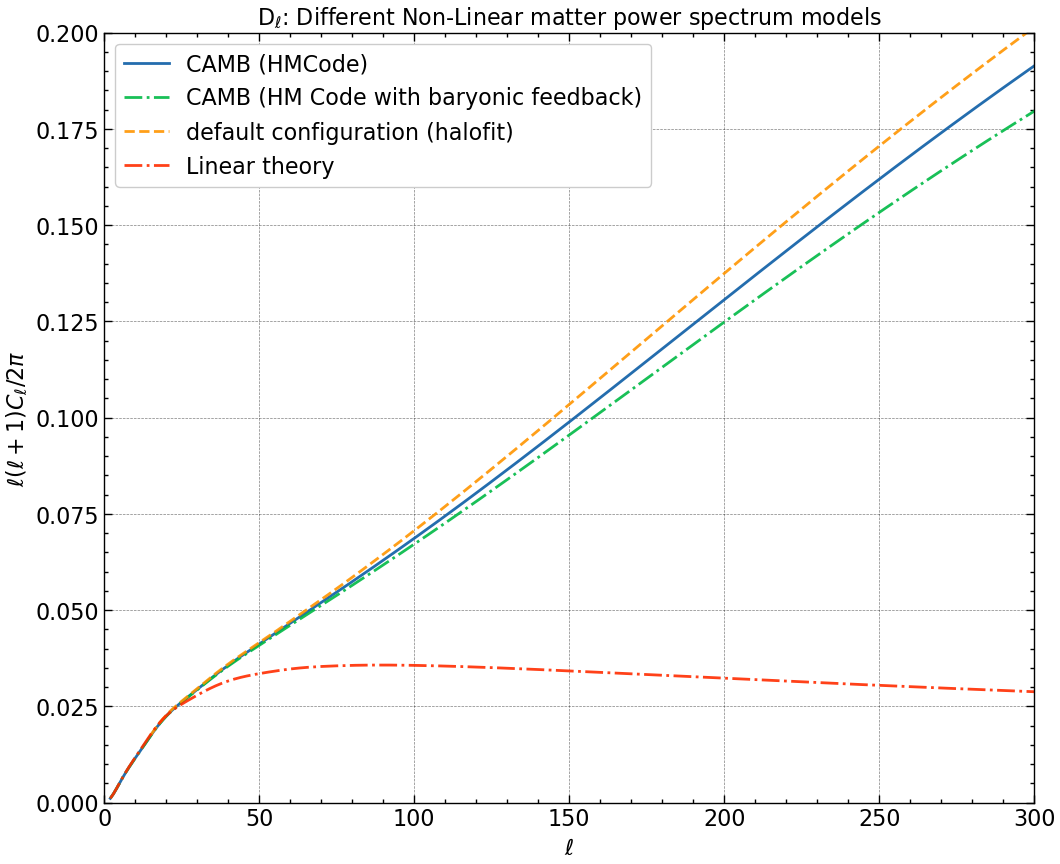

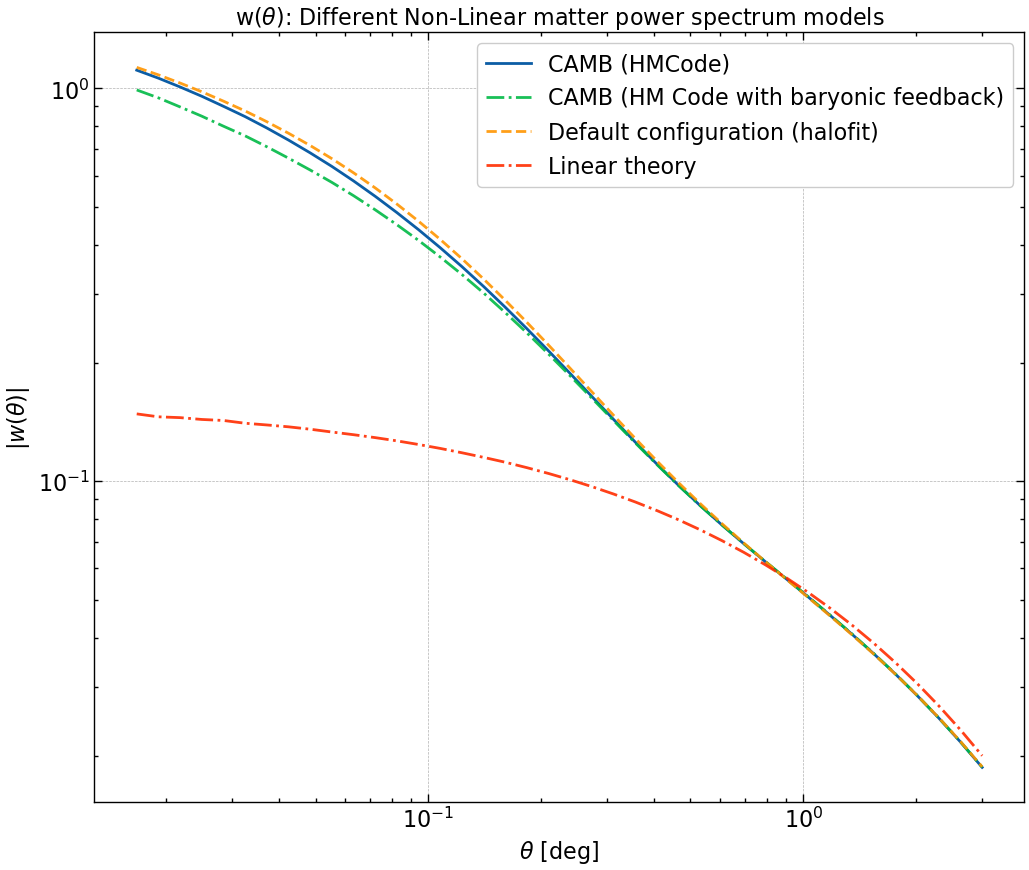

In [ ]:

plt.figure(figsize=(12,10))

z=samples_sorted
n_z = y_samples_sorted
gal_tracer = ccl.NumberCountsTracer(cosmo, has_rsd=False, dndz=(z, n_z), bias=(z, np.ones_like(z)))
ell1 = np.arange(15, 400)

def dll(a,ell):
    cls_gg = ccl.angular_cl(cosmo, gal_tracer, gal_tracer, ell)
    dl=ell*(ell+1)*cls_gg/2/np.pi
    return a*dl 

def w_theta_default(ell):
    cls_gg = ccl.angular_cl(cosmo, gal_tracer, gal_tracer, ell)

    return ccl.correlation(theta = theta, ell = ell, C_ell = cls_gg, cosmo = cosmo)

plt.plot(ell, ell*(ell+1)*cl_hm/2/np.pi, label="CAMB (HMCode)",alpha=0.9)
plt.plot(ell, ell*(ell+1)*cl_hm2/2/np.pi, label="CAMB (HM Code with baryonic feedback)",alpha=0.9,ls= '-.')

plt.plot(ell1,dll(1,ell1),label = 'default configuration (halofit)',alpha=0.9,ls='--')

plt.plot(ell, ell*(ell+1)*cl_lin/2/np.pi, label="Linear theory",alpha =0.9,ls ='-.')
plt.title("D$_\ell$: Different Non-Linear matter power spectrum models")
plt.ylabel(r"$\ell(\ell+1)C_\ell/2\pi$")
plt.xlabel(r"$\ell$")
plt.legend()
plt.xlim(0,300)
plt.ylim(0,0.20)


plt.figure(figsize=(12,10))
plt.loglog(theta, np.abs(wtheta_hm), label="CAMB (HMCode)")
plt.loglog(theta, np.abs(wtheta_hm2), label="CAMB (HM Code with baryonic feedback)",ls='-.',alpha=0.9)
plt.loglog(theta, np.abs(w_theta_default(ell)), label="Default configuration (halofit)",ls='--',alpha=0.9)
plt.loglog(theta, np.abs(wtheta_lin), label="Linear theory",ls='-.',alpha=0.9)
plt.title(r"w($\theta$): Different Non-Linear matter power spectrum models")

plt.xlabel(r"$\theta$ [deg]")
plt.ylabel(r"$|w(\theta)|$")
plt.legend()
plt.grid(alpha=0.3)
plt.show()



In [ ]:
8591269166

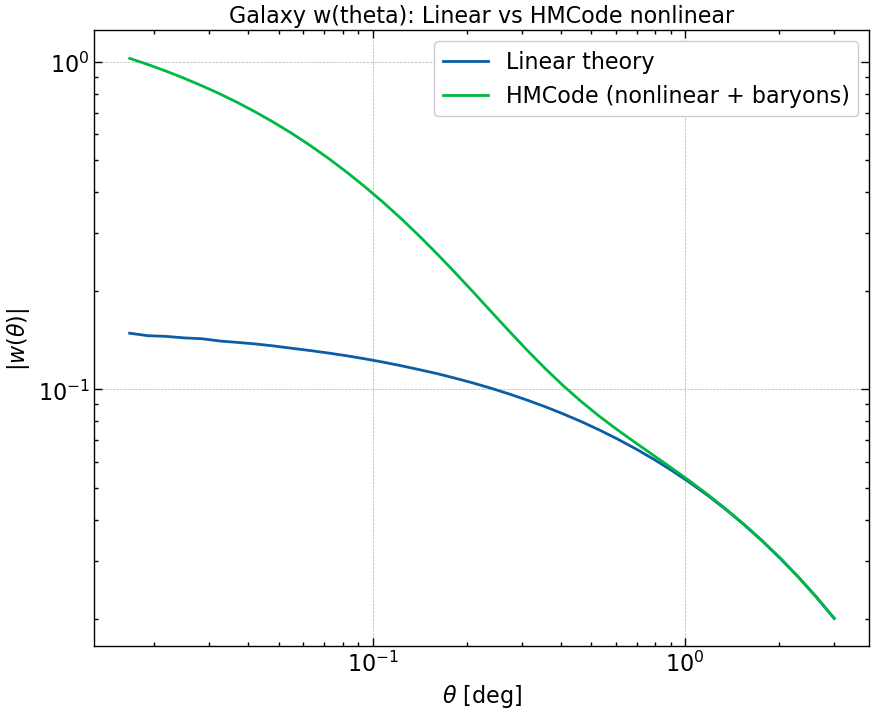

In [ ]:
plt.figure(figsize=(10,8))

plt.loglog(theta, np.abs(wtheta_lin), label="Linear theory")
plt.loglog(theta, np.abs(wtheta_hm), label="HMCode (nonlinear + baryons)")


plt.xlabel(r"$\theta$ [deg]")
plt.ylabel(r"$|w(\theta)|$")
plt.title("Galaxy w(theta): Linear vs HMCode nonlinear")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

(0.0, 300.0)

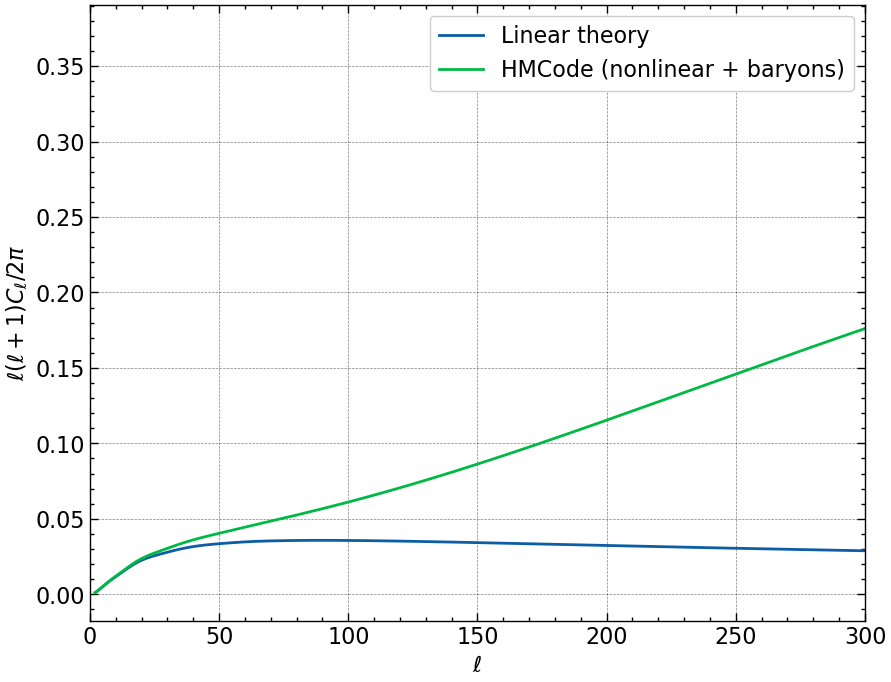

In [ ]:
plt.figure(figsize=(10,8))
plt.plot(ell, ell*(ell+1)*cl_lin/2/np.pi, label="Linear theory")
plt.plot(ell, ell*(ell+1)*cl_hm/2/np.pi, label="HMCode (nonlinear + baryons)")
plt.ylabel(r"$\ell(\ell+1)C_\ell/2\pi$")
plt.xlabel(r"$\ell$")
plt.legend()
plt.xlim(0,300)
#plt.ylim(0,0.06)


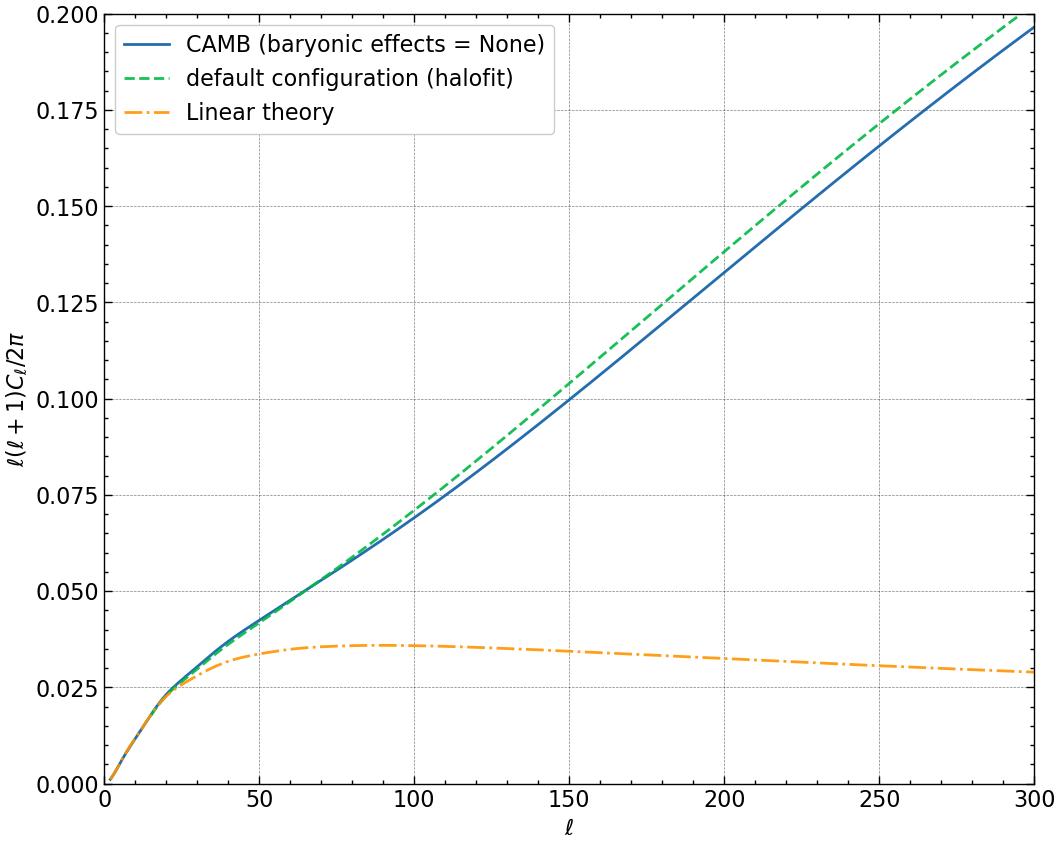

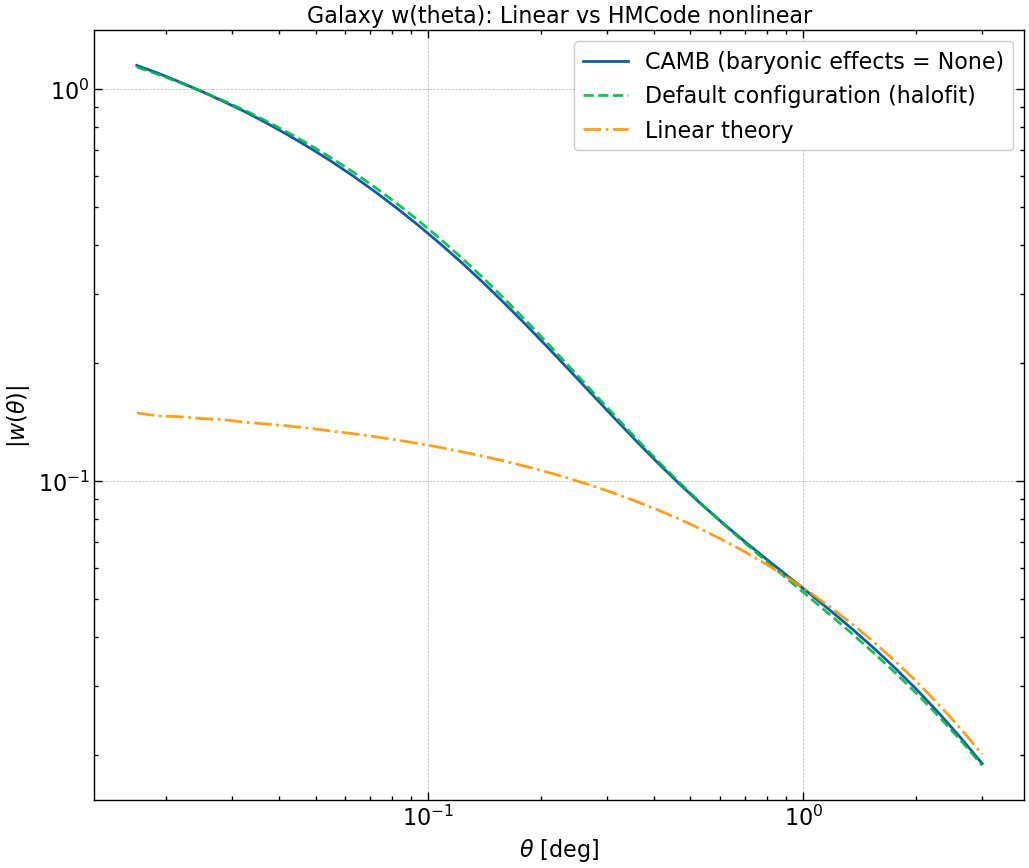

In [ ]:
cosmo = ccl.Cosmology(
    Omega_c=0.264,  # Cold dark matter density
    Omega_b=0.049,  # Baryon density
    h=0.674,        # Hubble parameter
    sigma8=0.811,    # Power spectrum normalization
    n_s=0.965       # Spectral index
    
)
plt.figure(figsize=(12,10))

z=samples_sorted
n_z = y_samples_sorted
gal_tracer = ccl.NumberCountsTracer(cosmo, has_rsd=False, dndz=(z, n_z), bias=(z, np.ones_like(z)))
ell1 = np.arange(15, 400)

def dll(a,ell):
    cls_gg = ccl.angular_cl(cosmo, gal_tracer, gal_tracer, ell)
    dl=ell*(ell+1)*cls_gg/2/np.pi
    return a*dl 

def w_theta_default(ell):
    cls_gg = ccl.angular_cl(cosmo, gal_tracer, gal_tracer, ell)

    return ccl.correlation(theta = theta, ell = ell, C_ell = cls_gg, cosmo = cosmo)

plt.plot(ell, ell*(ell+1)*cl_hm/2/np.pi, label="CAMB (baryonic effects = None)",alpha=0.9)
plt.plot(ell1,dll(1,ell1),label = 'default configuration (halofit)',alpha=0.9,ls='--')

plt.plot(ell, ell*(ell+1)*cl_lin/2/np.pi, label="Linear theory",alpha =0.9,ls ='-.')

plt.ylabel(r"$\ell(\ell+1)C_\ell/2\pi$")
plt.xlabel(r"$\ell$")
plt.legend()
plt.xlim(0,300)
plt.ylim(0,0.20)


plt.figure(figsize=(12,10))
plt.loglog(theta, np.abs(wtheta_hm), label="CAMB (baryonic effects = None)")
plt.loglog(theta, np.abs(w_theta_default(ell)), label="Default configuration (halofit)",ls='--',alpha=0.9)
plt.loglog(theta, np.abs(wtheta_lin), label="Linear theory",ls='-.',alpha=0.9)


plt.xlabel(r"$\theta$ [deg]")
plt.ylabel(r"$|w(\theta)|$")
plt.title("Galaxy w(theta): Linear vs HMCode nonlinear")
plt.legend()
plt.grid(alpha=0.3)
plt.show()



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pyccl as ccl

# ---------- Common setup ----------
cosmo_params = dict(
    Omega_c=0.25, Omega_b=0.05, h=0.67,
    sigma8=0.81, n_s=0.965,
    transfer_function="boltzmann_camb"
)

z = np.linspace(0, 2, 300)
nz = np.exp(-0.5*((z-0.8)/0.3)**2); nz /= np.trapz(nz, z)
bz = 1.5 + 0.5*z

# 1 arcmin to 3 deg, in DEGREES
theta = np.logspace(np.log10(1/60), np.log10(3), 50)
# Go high in ell for small-angle behaviour
ell = np.arange(2, 20000)

def cosine_taper(x, x0, x1):
    f = np.ones_like(x, dtype=float)
    m = (x>=x0) & (x<=x1)
    f[x>x1] = 0.0
    f[m] = 0.5*(1 + np.cos(np.pi*(x[m] - x0)/(x1 - x0)))
    return f

tap = cosine_taper(ell, 12000, 18000)

# ---------- Linear ----------
cosmo_lin = ccl.Cosmology(**cosmo_params, matter_power_spectrum="linear")
tr = ccl.NumberCountsTracer(cosmo_lin, dndz=(z, nz), bias=(z, bz), has_rsd=False)
cl_lin = ccl.angular_cl(cosmo_lin, tr, tr, ell)

# ---------- HMCode nonlinear ----------
cosmo_hm = ccl.Cosmology(
    **cosmo_params,
    matter_power_spectrum="halofit",  # yes, the name is misleading
    extra_parameters={"camb": {
        "halofit_version": "mead2020_feedback",  # HMCode2020 feedback
        "HMCode_logT_AGN": 7.8                   # baryon strength
    }}
)
tr_hm = ccl.NumberCountsTracer(cosmo_hm, dndz=(z, nz), bias=(z, bz), has_rsd=False)
cl_hm = ccl.angular_cl(cosmo_hm, tr_hm, tr_hm, ell)

# ---------- Sanity: P(k) suppression at high k ----------
k = np.logspace(-2, 1.3, 200)  # 0.01..20 h/Mpc
pk_lin = ccl.linear_matter_power(cosmo_lin, k, 0.5)
pk_hm  = ccl.nonlin_matter_power(cosmo_hm,  k, 0.5)

# ---------- Sanity: C_ell suppression ----------
# Optional shot noise (per steradian), comment both or keep both
# nbar = 3e8
# cl_lin = cl_lin + 1/nbar; cl_hm = cl_hm + 1/nbar

# Taper to reduce ringing in the θ transform
cl_lin_t = cl_lin * tap
cl_hm_t  = cl_hm  * tap

# ---------- w(theta) in configuration space (signed, not abs) ----------
w_lin = ccl.correlation(theta=theta, ell=ell, C_ell=cl_lin_t, cosmo=cosmo_lin)
w_hm  = ccl.correlation(theta=theta, ell=ell, C_ell=cl_hm_t,  cosmo=cosmo_hm)

# ---------- Plots ----------
plt.figure(figsize=(6.5,4.5))
plt.loglog(theta, np.maximum(w_lin, 1e-20), label='Linear')
plt.loglog(theta, np.maximum(w_hm,  1e-20), label='HMCode')
plt.xlabel(r'$\theta$ [deg]'); plt.ylabel(r'$w(\theta)$')
plt.title('w(θ): Linear vs HMCode'); plt.legend(); plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(6.5,3.8))
ratio = w_hm / w_lin
plt.semilogx(theta, ratio)
plt.axhline(1, ls='--', lw=1, color='k')
plt.xlabel(r'$\theta$ [deg]'); plt.ylabel('HMCode / Linear')
plt.title('Suppression from HMCode'); plt.grid(alpha=0.3)
plt.show()

# Optional checks if you want to eyeball the ingredients:
plt.figure(figsize=(6.5,4.5))
plt.loglog(k, pk_lin, label='P_lin(z=0.5)')
plt.loglog(k, pk_hm, label='P_HMCode(z=0.5)')
plt.xlabel('k [h/Mpc]'); plt.ylabel('P(k)'); plt.legend(); plt.grid(alpha=0.3); plt.show()

plt.figure(figsize=(6.5,4.5))
plt.loglog(ell, cl_lin, label='C_ell linear')
plt.loglog(ell, cl_hm,  label='C_ell HMCode')
plt.xlabel('ℓ'); plt.ylabel(r'$C_\ell$'); plt.legend(); plt.grid(alpha=0.3); plt.show()


CCLError: Error CCL_ERROR_SPLINE: ccl_correlation.c: ccl_tracer_corr_fftlog(): failed to create spline


In [ ]:
w_lin = ccl.correlation(cosmo_lin, ell, cl_lin_t, theta, "GG")
w_hm  = ccl.correlation(cosmo_hm, ell, cl_hm_t, theta, "GG")



TypeError: correlation() takes 1 positional argument but 5 were given

In [ ]:
w_lin = ccl.correlation(cosmo_lin, ell, cl_lin_t, theta, type='NN')
w_hm  = ccl.correlation(cosmo_hm,  ell, cl_hm_t,  theta, type='NN')


TypeError: correlation() takes 1 positional argument but 4 positional arguments (and 1 keyword-only argument) were given